[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter12_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 12: Machine learning and deep learning for time series

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Validation for dependent data: the Bergmeir-Hyndman-Koo (2018) design; leakage through overlapping targets.
- Global and local models of EU inflation; lasso, adaptive lasso and elastic net on the EU panel.
- Tree ensembles for Romanian day-ahead load: QRF, boosting with monotone constraints, the expert ARX.
- Recurrent networks: vanishing gradients; deep models against HAR for realised variance.
- The Zeng et al. (2023) protocol: linear models against Transformers; N-BEATS, N-HiTS and DeepAR on M4 hourly.
- Interpretation (Shapley values, attention against occlusion), seeds and data snooping, the AI mini-case.
- Smaller settings than the slides (fewer replications, seeds, epochs and assets) keep the run to minutes.
- Data: Romanian hourly load from Energy-Charts (ENTSO-E transparency data, public API); Eurostat HICP of the 27 EU countries; the Oxford-Man realized library v0.3 (downloaded by `read_omi` from the Internet Archive copy) and our Binance realised measures (`data/realized` of the ATS repository); the M4 hourly series and the official M4 evaluation file (M4-methods repository).
- PyTorch runs on the CPU with small networks and fixed seeds; results can differ slightly across PyTorch versions.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
# PyTorch, scikit-learn and openpyxl are preinstalled in Colab
# !pip install torch scikit-learn openpyxl

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The engine and the data helpers

- Evaluation: `dm_test`, `mcs`, `qlike`, `pinball`, `smape`, `mase`.
- Validation: `embed`, `bhk_trial`, `purged_folds`; penalised regression: `penalised_fit`; forests: `QRF`.
- Networks: `MLPNet`, `RNNNet`, `TCNNet`, `LinearNet`, `PatchTransformer`, `NBeatsNet`, `DeepARNet`, trained by `fit_torch`.
- Interpretation: `shapley_groups`.

In [6]:
import io
import sys
import math
import itertools
import urllib.error
try:                                            # PyTorch is preinstalled in Colab
    import torch
    from torch import nn
    TORCH = True
except ImportError:
    import types
    torch = None
    nn = types.SimpleNamespace(Module=object)
    TORCH = False
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                 if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
OMI_NAMES = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', '.FTSE': 'FTSE 100', '.N225': 'Nikkei 225', '.STOXX50E': 'Euro Stoxx 50', '.FCHI': 'CAC 40'}
LOAD_API = 'https://api.energy-charts.info/public_power?country=ro&start={a}&end={b}'
LOAD_YEARS = (2023, 2024, 2025, 2026)
LOAD_END = '2026-09-30'
LOAD_EVAL = '2025-01-01'
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
HICP = ('prc_hicp_minr', 'M.RCH_A.TOTAL.')
INFL = {'start': '2000-01-01', 'first': '2015-01-01', 'win': 120, 'lags': (1, 2, 3, 6, 12, 18, 24, 36), 'x_lags': 3}
M4_RAW = 'https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/'
M4H = {'H': 48, 'm': 24, 'L': 336}
ZENG = {'L': 336, 'horizons': (96, 336), 'split': (0.7, 0.1, 0.2)}
RV = {'lags': 22, 'first': 2500, 'refit': 500, 'horizons': (1, 5, 22)}
TAUS9 = np.arange(1, 10) / 10
MONO = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
DEEPAR_LAGS = (1, 24, 168)
_MEM = {}


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder in ATS_CACHE."""
    import hashlib
    import time
    if url in _MEM:
        return _MEM[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _MEM[url] = open(path, 'rb').read()
        return _MEM[url]
    for attempt in range(6):                    # the Energy-Charts API limits the request rate
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _MEM[url] = urllib.request.urlopen(req, timeout=180).read()
            break
        except urllib.error.HTTPError as e:
            if e.code != 429 or attempt == 5:
                raise
            time.sleep(15 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_MEM[url])
    return _MEM[url]


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def omi(symbol='.SPX', col='rv5'):
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): daily 5-minute realised variance
    of one index, in %^2; non-positive days dropped."""
    if 'omi' not in _MEM:
        _MEM['omi'] = read_omi()
    d = _MEM['omi']
    s = d[d['symbol'] == symbol].set_index('date').sort_index()[col] * 1e4
    return s[s > 0].dropna().rename(OMI_NAMES[symbol])


def ro_load_hourly():
    """Romanian hourly electricity load (GW), local time, 2023 to LOAD_END (Energy-Charts, ENTSO-E transparency data):
    15-minute values averaged within each hour; a days x 24 table (DST days: 23 or 25 hours become 24)."""
    import json as _json
    if 'load' in _MEM:
        return _MEM['load']
    parts = []
    for y in LOAD_YEARS:
        b = min(f'{y}-12-31', LOAD_END)
        d = _json.loads(get_bytes(LOAD_API.format(a=f'{y}-01-01', b=b)))
        load = [x for x in d['production_types'] if x['name'] == 'Load'][0]['data']
        parts.append(pd.Series(load, index=pd.to_datetime(d['unix_seconds'], unit='s', utc=True), dtype=float))
    s = pd.concat(parts).sort_index()
    s = s[~s.index.duplicated()].tz_convert('Europe/Bucharest')
    df = pd.DataFrame({'y': s.values, 'day': s.index.tz_localize(None).normalize(), 'hour': s.index.hour})
    tab = df.groupby(['day', 'hour'])['y'].mean().unstack('hour')
    tab = tab.interpolate(axis=1, limit_direction='both').interpolate(axis=0, limit_direction='both')
    _MEM['load'] = tab.loc[:LOAD_END] / 1000.0
    return _MEM['load']


def orthodox_easter(y):
    """Orthodox Easter (Gregorian date): Meeus' Julian algorithm plus 13 days (valid 1900-2099)."""
    a, b, c = y % 4, y % 7, y % 19
    d = (19 * c + 15) % 30
    e = (2 * a + 4 * b - d + 34) % 7
    mo, da = divmod(d + e + 114, 31)
    return pd.Timestamp(y, mo, da + 1) + pd.Timedelta(days=13)


def ro_holidays(years):
    """Romanian public holidays: fixed dates, Orthodox Good Friday, Easter and Pentecost (Sunday and Monday)."""
    out = []
    for y in years:
        fixed = ['01-01', '01-02', '01-24', '05-01', '06-01', '08-15', '11-30', '12-01', '12-25', '12-26']
        fixed += ['01-06', '01-07'] if y >= 2024 else []
        out += [pd.Timestamp(f'{y}-{m}') for m in fixed]
        e = orthodox_easter(y)
        out += [e + pd.Timedelta(days=k) for k in (-2, 0, 1, 49, 50)]
    return pd.DatetimeIndex(sorted(set(out)))


def eu_hicp():
    """Annual HICP inflation (%), monthly, of the 27 EU countries (Eurostat prc_hicp_minr, all items), common sample."""
    if 'hicp' in _MEM:
        return _MEM['hicp']
    url = ('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/' + HICP[0] + '/' + HICP[1] + '+'.join(EU27)
           + '?format=SDMX-CSV&startPeriod=1999-01')
    t = pd.read_csv(io.BytesIO(get_bytes(url)))
    t['date'] = pd.to_datetime(t['TIME_PERIOD'] + '-01')
    P = t.pivot_table(index='date', columns='geo', values='OBS_VALUE')[EU27].loc[INFL['start']:]
    _MEM['hicp'] = P.dropna()
    return _MEM['hicp']


def m4_hourly():
    """The hourly subset of the M4 competition (414 series): training parts (list of arrays) and test parts (414 x 48)."""
    if 'm4' in _MEM:
        return _MEM['m4']
    tr = pd.read_csv(io.BytesIO(get_bytes(M4_RAW + 'Train/Hourly-train.csv')), index_col=0)
    te = pd.read_csv(io.BytesIO(get_bytes(M4_RAW + 'Test/Hourly-test.csv')), index_col=0)
    train = [r.dropna().values.astype(float) for _, r in tr.iterrows()]
    _MEM['m4'] = (train, te.values.astype(float), list(tr.index))
    return _MEM['m4']


def hac_var(x, lags, kernel='bartlett', center=True):
    """Long-run variance of a series: Bartlett (Newey-West) or rectangular (truncated) kernel."""
    x = np.asarray(x, float)
    x = x - x.mean() if center else x
    T = len(x)
    v = x @ x / T
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1) if kernel == 'bartlett' else 1.0
        v += 2 * w * (x[k:] @ x[:-k]) / T
    return v


def dm_test(d, h=1, kernel='rect', lags=None):
    """Diebold-Mariano test of E[d] = 0 for the loss differential d (model 1 minus model 2), HAC variance with h - 1
    lags (rectangular; Bartlett if negative) and the Harvey-Leybourne-Newbold correction with t(T - 1)."""
    d = np.asarray(d, float)
    d = d[~np.isnan(d)]
    T = len(d)
    L = h - 1 if lags is None else lags
    v = hac_var(d, L, kernel)
    if v <= 0:
        v = hac_var(d, L, 'bartlett')
    dm = d.mean() / np.sqrt(v / T)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T) * dm
    return {'T': T, 'dbar': float(d.mean()), 'dm': float(dm), 'hln': float(hln),
            'p_hln': float(2 * stats.t.sf(abs(hln), T - 1))}


def mcs(losses, alpha=0.10, B=2000, block=7, seed=2026):
    """Model Confidence Set (Hansen, Lunde and Nason 2011), T_max statistic, moving-block bootstrap.
    losses: T x m DataFrame; returns the MCS p-value of every model and the set at level alpha."""
    L = np.asarray(losses, float)
    L = L[~np.isnan(L).any(axis=1)]
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, T - block + 1, size=(B, nb)).ravel()])
    idx = idx.reshape(B, nb * block)[:, :T]
    Lb = L[idx].mean(axis=1)
    alive, pvals, p_run = list(range(m)), {}, 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        p = float((((db - dbar) / se).max(axis=1) > t.max()).mean())
        p_run = max(p_run, p)
        worst = alive[int(np.argmax(t))]
        pvals[worst] = p_run
        alive.remove(worst)
    pvals[alive[0]] = 1.0
    cols = list(losses.columns) if hasattr(losses, 'columns') else list(range(m))
    out = {cols[i]: pvals[i] for i in range(m)}
    return {'p': out, 'set': [c for c in cols if out[c] >= alpha]}


def qlike(rv, f):
    """QLIKE loss of a variance forecast f for the realised variance rv (Patton 2011)."""
    x = np.asarray(rv, float) / np.asarray(f, float)
    return x - np.log(x) - 1


def pinball(y, q, tau):
    """Pinball (quantile) loss of the tau-quantile forecast q."""
    u = np.asarray(y, float) - np.asarray(q, float)
    return np.maximum(tau * u, (tau - 1) * u)


def smape(y, f):
    """Symmetric MAPE of the M4 competition, in % (Makridakis, Spiliotis and Assimakopoulos 2020)."""
    y, f = np.asarray(y, float), np.asarray(f, float)
    return 200 * np.mean(np.abs(y - f) / (np.abs(y) + np.abs(f)))


def mase(y, f, insample, m):
    """Mean absolute scaled error (Hyndman and Koehler 2006): scale = in-sample MAE of the seasonal naive forecast."""
    x = np.asarray(insample, float)
    return np.mean(np.abs(np.asarray(y, float) - np.asarray(f, float))) / np.mean(np.abs(x[m:] - x[:-m]))


def embed(y, p):
    """Rows t = p, ..., n - 1: X[t] = (y_{t-1}, ..., y_{t-p}), target y_t."""
    y = np.asarray(y, float)
    n = len(y)
    X = np.column_stack([y[p - k:n - k] for k in range(1, p + 1)])
    return X, y[p:]


def ols(Xtr, ytr, Xte):
    """OLS with an intercept: predictions for Xte."""
    A = np.column_stack([np.ones(len(Xtr)), Xtr])
    b = np.linalg.lstsq(A, ytr, rcond=None)[0]
    return np.column_stack([np.ones(len(Xte)), Xte]) @ b


def loocv_ols(X, y):
    """Leave-one-out residuals of OLS with an intercept in closed form, e_i / (1 - h_ii)."""
    A = np.column_stack([np.ones(len(X)), X])
    Q, _ = np.linalg.qr(A)
    h = (Q ** 2).sum(axis=1)
    e = y - Q @ (Q.T @ y)
    return e / (1 - h)


def ar_sim(phi, n, burn=100, rng=None, theta=None, sigma=1.0):
    """Gaussian ARMA path: phi (AR coefficients, any lags), theta (MA coefficients)."""
    rng = rng or np.random.default_rng()
    phi = np.asarray(phi, float)
    theta = np.asarray(theta if theta is not None else [], float)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        v = e[t]
        for k in range(1, q + 1):
            if t - k >= 0:
                v += theta[k - 1] * e[t - k]
        for k in range(1, p + 1):
            if t - k >= 0:
                v += phi[k - 1] * x[t - k]
        x[t] = v
    return x[burn:]


def random_stationary_ar(p, rng):
    """AR(p) coefficients drawn uniformly on [-1, 1]^p and kept if the process is stationary (rejection sampling)."""
    while True:
        phi = rng.uniform(-1, 1, p)
        if np.all(np.abs(np.roots(np.r_[1.0, -phi])) < 1):
            return phi


def bhk_trial(y, pmax=5, k=5, in_frac=0.7, rng=None):
    """One Monte Carlo trial of Bergmeir, Hyndman and Koo (2018, Section 4): in-set 70%, out-set 30%; AR(1)..AR(pmax)
    by OLS; RMSE estimated by 5-fold CV, LOOCV, non-dependent CV (training rows within pmax lags of a test row
    removed) and OOS (last 20% of the in-set); the 'true' RMSE: model fitted on the whole in-set, one-step forecasts
    of the out-set. Returns a dict model -> procedure -> RMSE."""
    rng = rng or np.random.default_rng()
    y = np.asarray(y, float)
    n = len(y)
    T = int(round(in_frac * n))
    X, z = embed(y, pmax)                           # rows t = pmax..n-1
    tt = np.arange(pmax, n)
    inn = tt < T
    Xi, zi, ti = X[inn], z[inn], tt[inn]
    Xo, zo = X[~inn], z[~inn]
    m = len(zi)
    folds = rng.permutation(np.arange(m) % k)
    n_oos = int(round(0.2 * m))
    out = {}
    for p in range(1, pmax + 1):
        A = Xi[:, :p]
        e5, en = np.empty(m), np.empty(m)
        for f in range(k):
            te = folds == f
            e5[te] = zi[te] - ols(A[~te], zi[~te], A[te])
            far = np.ones(m, bool)
            for t0 in ti[te]:
                far &= np.abs(ti - t0) >= pmax
            en[te] = zi[te] - ols(A[far], zi[far], A[te])
        eo = zi[-n_oos:] - ols(A[:-n_oos], zi[:-n_oos], A[-n_oos:])
        etrue = zo - ols(A, zi, Xo[:, :p])
        r = lambda e: float(np.sqrt(np.mean(e ** 2)))
        out[f'AR({p})'] = {'5-fold CV': r(e5), 'LOOCV': r(loocv_ols(A, zi)), 'nonDepCV': r(en), 'OOS': r(eo),
                           'true': r(etrue)}
    return out


def purged_folds(n, k, gap):
    """Blocked k-fold for rows 0..n-1 with a purge: training rows within `gap` of the test block are removed."""
    edges = np.linspace(0, n, k + 1).astype(int)
    for a, b in zip(edges[:-1], edges[1:]):
        te = np.arange(a, b)
        tr = np.r_[np.arange(0, max(a - gap, 0)), np.arange(min(b + gap, n), n)]
        yield tr, te


def standardise(Xtr, Xte):
    mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
    sd = np.where(sd > 0, sd, 1.0)
    return (Xtr - mu) / sd, (Xte - mu) / sd


def penalised_fit(X, y, kind='lasso', keep=(), alphas=None, k=5, gap=12, l1_ratio=0.5, gamma=1.0):
    """Lasso, adaptive lasso (Zou 2006; weights |ridge coefficient|^gamma) or elastic net (Zou and Hastie 2005) on
    standardised features; the columns in `keep` are not penalised (partialled out by OLS, Frisch-Waugh-Lovell).
    The penalty is chosen by blocked k-fold CV with a purge of `gap` rows (h-step targets).
    Returns (intercept, coefficients on the original scale, chosen alpha, selected mask of the penalised columns)."""
    from sklearn.linear_model import ElasticNet, Lasso, Ridge
    X = np.asarray(X, float)
    keep = list(keep)
    pen = [j for j in range(X.shape[1]) if j not in keep]
    K = np.column_stack([np.ones(len(y))] + [X[:, j] for j in keep])
    proj = lambda v: v - K @ np.linalg.lstsq(K, v, rcond=None)[0]
    Xp, yp = proj(X[:, pen]), proj(y)
    sd = Xp.std(axis=0)
    sd = np.where(sd > 0, sd, 1.0)
    Z = Xp / sd
    w = np.ones(len(pen))
    if kind == 'adaptive':
        w = np.abs(Ridge(alpha=1.0).fit(Z, yp).coef_) ** gamma + 1e-8
    Zw = Z * w
    if alphas is None:
        alphas = np.geomspace(1.0, 1e-3, 20) * np.max(np.abs(Zw.T @ yp)) / len(y)

    def model(a):
        if kind == 'enet':
            return ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=20000, fit_intercept=False)
        return Lasso(alpha=a, max_iter=20000, fit_intercept=False)
    cv = np.zeros(len(alphas))
    for tr, te in purged_folds(len(y), k, gap):
        for i, a in enumerate(alphas):
            cv[i] += np.sum((yp[te] - model(a).fit(Zw[tr], yp[tr]).predict(Zw[te])) ** 2)
    a = alphas[int(np.argmin(cv))]
    bp = model(a).fit(Zw, yp).coef_ * w / sd
    beta = np.zeros(X.shape[1])
    beta[pen] = bp
    bk = np.linalg.lstsq(K, y - X[:, pen] @ bp, rcond=None)[0]
    beta[keep] = bk[1:]
    return float(bk[0]), beta, float(a), np.abs(bp) > 0


class QRF:
    """Quantile regression forest (Meinshausen 2006): a random forest whose leaves keep all training targets;
    the conditional distribution at x is the weighted empirical distribution with weights
    w_i(x) = (1/B) sum_b 1{x_i in leaf_b(x)} / |leaf_b(x)|."""

    def __init__(self, n_estimators=100, min_samples_leaf=10, max_features=0.5, seed=0):
        from sklearn.ensemble import RandomForestRegressor
        self.rf = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf,
                                        max_features=max_features, random_state=seed, n_jobs=1)

    def fit(self, X, y):
        self.rf.fit(X, y)
        self.y = np.asarray(y, float)
        self.order = np.argsort(self.y)
        self.leaves = self.rf.apply(X)              # n x B
        return self

    def weights(self, X):
        Lte = self.rf.apply(X)
        n, B = self.leaves.shape
        W = np.zeros((len(X), n))
        for b in range(B):
            lt = self.leaves[:, b]
            cnt = np.bincount(lt)
            same = Lte[:, b][:, None] == lt[None, :]
            W += same / cnt[lt][None, :]
        return W / B

    def predict(self, X):
        return self.rf.predict(X)

    def quantiles(self, X, taus):
        W = self.weights(X)[:, self.order]
        C = np.cumsum(W, axis=1)
        ys = self.y[self.order]
        return np.column_stack([ys[np.minimum((C < t).sum(axis=1), len(ys) - 1)] for t in taus])


def set_seed(seed):
    np.random.seed(seed)
    if TORCH:
        torch.manual_seed(seed)


class MLPNet(nn.Module):
    """Multilayer perceptron: L inputs -> hidden (ReLU) -> H outputs."""

    def __init__(self, L, H, hidden=32, layers=2):
        super().__init__()
        mods, d = [], L
        for _ in range(layers):
            mods += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        self.net = nn.Sequential(*mods, nn.Linear(d, H))

    def forward(self, x):
        return self.net(x)


class RNNNet(nn.Module):
    """Recurrent network (kind = 'rnn', 'lstm' or 'gru') on the input window; the last hidden state is mapped to H outputs."""

    def __init__(self, H, hidden=16, kind='lstm', layers=1):
        super().__init__()
        cell = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[kind]
        self.rnn = cell(1, hidden, num_layers=layers, batch_first=True)
        self.out = nn.Linear(hidden, H)

    def forward(self, x):
        o, _ = self.rnn(x.unsqueeze(-1))
        return self.out(o[:, -1])


class TCNNet(nn.Module):
    """Temporal convolutional network (Bai, Kolter and Koltun 2018): residual blocks of two dilated causal
    convolutions (kernel k, dilations 1, 2, 4, ...); receptive field 1 + 2 (k - 1)(2^levels - 1)."""

    def __init__(self, H, channels=16, k=3, levels=4):
        super().__init__()
        self.k = k
        self.convs = nn.ModuleList()
        self.skips = nn.ModuleList()
        c_in = 1
        for i in range(levels):
            d = 2 ** i
            self.convs.append(nn.ModuleList([nn.Conv1d(c_in, channels, k, dilation=d), nn.Conv1d(channels, channels, k, dilation=d)]))
            self.skips.append(nn.Conv1d(c_in, channels, 1) if c_in != channels else nn.Identity())
            c_in = channels
        self.out = nn.Linear(channels, H)

    def forward(self, x):
        z = x.unsqueeze(1)
        for (c1, c2), sk in zip(self.convs, self.skips):
            d = c1.dilation[0]
            pad = (self.k - 1) * d
            u = torch.relu(c1(nn.functional.pad(z, (pad, 0))))
            u = torch.relu(c2(nn.functional.pad(u, (pad, 0))))
            z = torch.relu(u + sk(z))
        return self.out(z[:, :, -1])


class LinearNet(nn.Module):
    """The linear baselines of Zeng et al. (2023): 'linear' (one layer on the window), 'nlinear' (the last value is
    subtracted and added back), 'dlinear' (moving-average trend + remainder, one linear layer each)."""

    def __init__(self, L, H, kind='dlinear', kernel=25):
        super().__init__()
        self.kind, self.kernel = kind, kernel
        self.lin = nn.Linear(L, H)
        if kind == 'dlinear':
            self.lin_t = nn.Linear(L, H)

    def forward(self, x):
        if self.kind == 'nlinear':
            last = x[:, -1:]
            return self.lin(x - last) + last
        if self.kind == 'dlinear':
            p = (self.kernel - 1) // 2
            xp = torch.cat([x[:, :1].repeat(1, p), x, x[:, -1:].repeat(1, self.kernel - 1 - p)], dim=1)
            trend = xp.unfold(1, self.kernel, 1).mean(-1)
            return self.lin(x - trend) + self.lin_t(trend)
        return self.lin(x)


class PatchTransformer(nn.Module):
    """A small patch Transformer in the spirit of PatchTST (Nie et al. 2023): instance normalisation, non-overlapping
    patches as tokens, learnable positional embedding, encoder layers with multi-head self-attention, a flatten head.
    The attention weights of the last forward pass are kept in self.attn (batch x tokens x tokens, head average)."""

    def __init__(self, L, H, patch=24, d=32, heads=4, layers=1, ff=64):
        super().__init__()
        self.patch, self.n_tok = patch, L // patch
        self.embed = nn.Linear(patch, d)
        self.pos = nn.Parameter(0.02 * torch.randn(1, self.n_tok, d))
        self.att = nn.ModuleList([nn.MultiheadAttention(d, heads, batch_first=True) for _ in range(layers)])
        self.ff = nn.ModuleList([nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d)) for _ in range(layers)])
        self.n1 = nn.ModuleList([nn.LayerNorm(d) for _ in range(layers)])
        self.n2 = nn.ModuleList([nn.LayerNorm(d) for _ in range(layers)])
        self.head = nn.Linear(self.n_tok * d, H)
        self.attn = None

    def forward(self, x):
        x = x[:, -self.n_tok * self.patch:]
        mu, sd = x.mean(1, keepdim=True), x.std(1, keepdim=True) + 1e-5
        z = ((x - mu) / sd).reshape(len(x), self.n_tok, self.patch)
        z = self.embed(z) + self.pos
        for att, ff, n1, n2 in zip(self.att, self.ff, self.n1, self.n2):
            a, w = att(z, z, z, need_weights=True, average_attn_weights=True)
            self.attn = w.detach()
            z = n1(z + a)
            z = n2(z + ff(z))
        return self.head(z.flatten(1)) * sd + mu


class NBeatsBlock(nn.Module):
    """One N-BEATS block (Oreshkin et al. 2020): a fully connected stack, then linear backcast and forecast.
    pool > 1 and n_coef < H give the N-HiTS block (Challu et al. 2023): max-pooled input and a forecast of n_coef
    coefficients interpolated linearly to H points."""

    def __init__(self, L, H, width=128, layers=3, pool=1, n_coef=None):
        super().__init__()
        self.L, self.H, self.pool = L, H, pool
        self.n_coef = n_coef or H
        mods, d = [], L // pool
        for _ in range(layers):
            mods += [nn.Linear(d, width), nn.ReLU()]
            d = width
        self.fc = nn.Sequential(*mods)
        self.back = nn.Linear(width, L)
        self.fore = nn.Linear(width, self.n_coef)

    def forward(self, x):
        u = x if self.pool == 1 else nn.functional.max_pool1d(x.unsqueeze(1), self.pool, self.pool).squeeze(1)
        h = self.fc(u)
        f = self.fore(h)
        if self.n_coef != self.H:
            f = nn.functional.interpolate(f.unsqueeze(1), size=self.H, mode='linear', align_corners=True).squeeze(1)
        return self.back(h), f


class NBeatsNet(nn.Module):
    """Doubly residual stacking: x_{l+1} = x_l - backcast_l, forecast = sum_l forecast_l. Generic N-BEATS:
    pools = (1, 1, ...); N-HiTS: pools = (8, 4, 1) with n_coefs = (H // 12, H // 4, H)."""

    def __init__(self, L, H, width=128, layers=3, pools=(1, 1, 1), n_coefs=None):
        super().__init__()
        n_coefs = n_coefs or [None] * len(pools)
        self.blocks = nn.ModuleList([NBeatsBlock(L, H, width, layers, p, c) for p, c in zip(pools, n_coefs)])

    def forward(self, x):
        scale = x.abs().mean(1, keepdim=True) + 1e-5     # each window divided by its mean absolute level
        r, f = x / scale, 0.0
        for b in self.blocks:
            bc, fc = b(r)
            r = r - bc
            f = f + fc
        return f * scale


def fit_torch(model, X, Y, epochs=60, lr=1e-3, batch=128, val_frac=0.2, patience=8, seed=0, loss='mse',
              weight_decay=0.0, max_steps=None):
    """Adam on mini-batches; the last val_frac of the (chronological) sample is the validation block for early
    stopping; the weights with the lowest validation loss are kept. loss: 'mse', 'mae' or a callable."""
    set_seed(seed)
    X = torch.as_tensor(np.asarray(X, np.float32))
    Y = torch.as_tensor(np.asarray(Y, np.float32))
    n = len(X)
    nv = int(round(val_frac * n))
    Xt, Yt, Xv, Yv = X[:n - nv], Y[:n - nv], X[n - nv:], Y[n - nv:]
    lf = {'mse': nn.functional.mse_loss, 'mae': nn.functional.l1_loss}.get(loss, loss)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    g = torch.Generator().manual_seed(seed)
    best, best_state, wait, steps = np.inf, None, 0, 0
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt), generator=g)
        for i in range(0, len(Xt), batch):
            j = perm[i:i + batch]
            opt.zero_grad()
            ls = lf(model(Xt[j]), Yt[j])
            ls.backward()
            opt.step()
            steps += 1
            if max_steps and steps >= max_steps:
                break
        model.eval()
        with torch.no_grad():
            v = float(lf(model(Xv), Yv)) if nv else float(ls)
        if v < best - 1e-7:
            best, wait = v, 0
            best_state = {k: t.clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
        if max_steps and steps >= max_steps:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def predict_torch(model, X, batch=4096):
    X = torch.as_tensor(np.asarray(X, np.float32))
    with torch.no_grad():
        return np.concatenate([model(X[i:i + batch]).numpy() for i in range(0, len(X), batch)])


def grad_through_time(kind, T=100, hidden=32, batch=64, seed=0, forget_bias=None):
    """Mean |d h_T / d x_t| (t = 1..T, summed over the units of h_T) for a freshly initialised RNN, LSTM or GRU
    (PyTorch default initialisation), Gaussian inputs: how far back the gradient reaches before any training.
    forget_bias: for the LSTM, the bias of the forget gate (0 at the default initialisation)."""
    set_seed(seed)
    cell = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[kind](1, hidden, batch_first=True)
    if kind == 'lstm' and forget_bias is not None:
        with torch.no_grad():
            cell.bias_ih_l0[hidden:2 * hidden] = forget_bias
            cell.bias_hh_l0[hidden:2 * hidden] = 0.0
    x = torch.randn(batch, T, 1, requires_grad=True)
    o, _ = cell(x)
    o[:, -1].sum().backward()
    return x.grad.abs().squeeze(-1).mean(0).numpy()


class DeepARNet(nn.Module):
    """A DeepAR-type model (Salinas et al. 2020): an LSTM over (scaled lagged targets at lags 1, 24, 168; sin and cos of
    the hour of the day) whose state gives the mean and the standard deviation of a Gaussian for the next scaled value."""

    def __init__(self, hidden=40, layers=2, n_in=len(DEEPAR_LAGS) + 2):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True)
        self.mu = nn.Linear(hidden, 1)
        self.sd = nn.Linear(hidden, 1)

    def forward(self, feat, state=None):
        o, state = self.lstm(feat, state)
        return self.mu(o).squeeze(-1), nn.functional.softplus(self.sd(o)).squeeze(-1) + 1e-3, state


def deepar_features(Z, P, j0, j1, lags=DEEPAR_LAGS, period=24):
    """Inputs for the targets at columns j0..j1-1 of the scaled segments Z (batch x length): the lagged values and the
    hour of the day of the target (positions P, same shape as Z)."""
    cols = np.arange(j0, j1)
    lagged = [Z[:, cols - l] for l in lags]
    a = 2 * np.pi * (P[:, cols] % period) / period
    return np.stack(lagged + [np.sin(a), np.cos(a)], -1).astype(np.float32)


def deepar_train(series, C, H, steps=1500, batch=64, lr=1e-3, seed=0, hidden=40, layers=2, lags=DEEPAR_LAGS, checkpoints=()):
    """Train on random segments of length max(lags) + C + H, with the Gaussian log-likelihood of the last C + H values
    given their lagged values (teacher forcing); each segment is divided by 1 + the mean of its context, as in DeepAR.
    checkpoints: steps at which a copy of the weights is kept (returned in net.checkpoints)."""
    set_seed(seed)
    rng = np.random.default_rng(seed)
    net = DeepARNet(hidden, layers, len(lags) + 2)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    M = max(lags)
    S = M + C + H
    ok = [i for i, s in enumerate(series) if len(s) > S]
    saved = {}
    for step in range(1, steps + 1):
        Z, P = [], []
        for i in rng.choice(ok, batch):
            a = rng.integers(0, len(series[i]) - S + 1)
            Z.append(series[i][a:a + S])
            P.append(np.arange(a, a + S))
        Z, P = np.array(Z, np.float32), np.array(P)
        Z = Z / (1 + Z[:, M:M + C].mean(1, keepdims=True))
        mu, sd, _ = net(torch.as_tensor(deepar_features(Z, P, M, S, lags)))
        y = torch.as_tensor(Z[:, M:S])
        nll = (torch.log(sd) + 0.5 * ((y - mu) / sd) ** 2).mean()
        opt.zero_grad()
        nll.backward()
        opt.step()
        if step in checkpoints:
            saved[step] = {k: v.clone() for k, v in net.state_dict().items()}
    net.eval()
    net.checkpoints = saved
    return net


def deepar_sample(net, histories, starts, C, H, n_samples=100, seed=0, lags=DEEPAR_LAGS):
    """Ancestral sampling of H steps after each history (array n x (max(lags) + C), the last values of a series whose
    first value has position `starts`): the LSTM runs over the context with the observed values, then each sampled
    value is fed back. Returns samples n x n_samples x H on the original scale."""
    set_seed(seed)
    Hst = np.asarray(histories, np.float32)
    n, M = len(Hst), max(lags)
    sc = 1 + Hst[:, M:M + C].mean(1, keepdims=True)
    Z = np.zeros((n * n_samples, M + C + H), np.float32)
    Z[:, :M + C] = np.repeat(Hst / sc, n_samples, 0)
    P = np.repeat(np.asarray(starts)[:, None] + np.arange(M + C + H)[None, :], n_samples, 0)
    with torch.no_grad():
        _, _, state = net(torch.as_tensor(deepar_features(Z, P, M, M + C, lags)))
        for k in range(H):
            j = M + C + k
            mu, sd, state = net(torch.as_tensor(deepar_features(Z, P, j, j + 1, lags)), state)
            Z[:, j] = (mu[:, 0] + sd[:, 0] * torch.randn(len(Z))).numpy()
    return Z[:, M + C:].reshape(n, n_samples, H) * sc[:, :, None]


def shapley_groups(predict, X, background, groups):
    """Exact interventional Shapley values of feature groups: v(S) = mean over the background rows of the prediction
    with the features of S taken from x and the others from the background row; phi_g = sum over S without g of
    |S|!(G - |S| - 1)!/G! [v(S + g) - v(S)]. Returns phi (n x G) and the base value v(empty)."""
    X, Bg = np.asarray(X, float), np.asarray(background, float)
    G = len(groups)
    n, nb = len(X), len(Bg)
    v = {}
    for r in range(G + 1):
        for S in itertools.combinations(range(G), r):
            Z = np.repeat(Bg[None], n, 0)
            for g in S:
                Z[:, :, groups[g]] = X[:, None, groups[g]]
            v[S] = predict(Z.reshape(n * nb, -1)).reshape(n, nb).mean(1)
    phi = np.zeros((n, G))
    for g in range(G):
        rest = [j for j in range(G) if j != g]
        for r in range(G):
            for S in itertools.combinations(rest, r):
                w = math.factorial(r) * math.factorial(G - r - 1) / math.factorial(G)
                phi[:, g] += w * (v[tuple(sorted(S + (g,)))] - v[S])
    return phi, float(v[()].mean())

## 1. Data and validation for dependent data

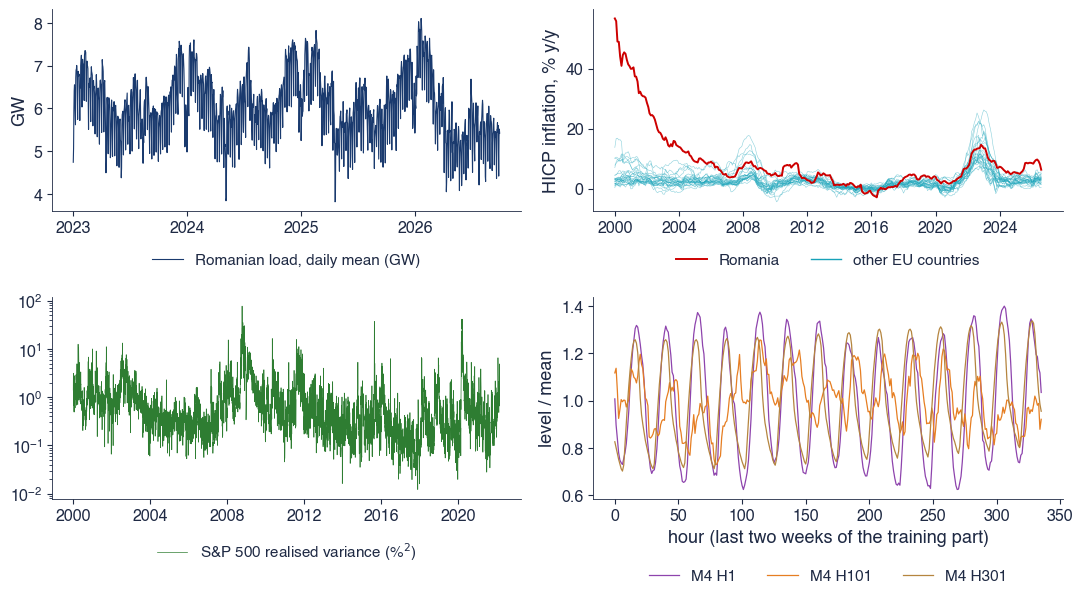

{'load_days': 1369, 'load_start': '2023-01-01', 'load_end': '2026-09-30', 'hicp_start': '2000-01-01', 'hicp_end': '2026-08-01', 'hicp_n': 320, 'rv_n': 5552, 'rv_start': '2000-01-03', 'rv_end': '2022-02-25', 'm4_n': 414, 'm4_min': 700, 'm4_max': 960, 'load_mean': 6.064305029142318, 'load_min': 2.54675, 'load_max': 9.20775}


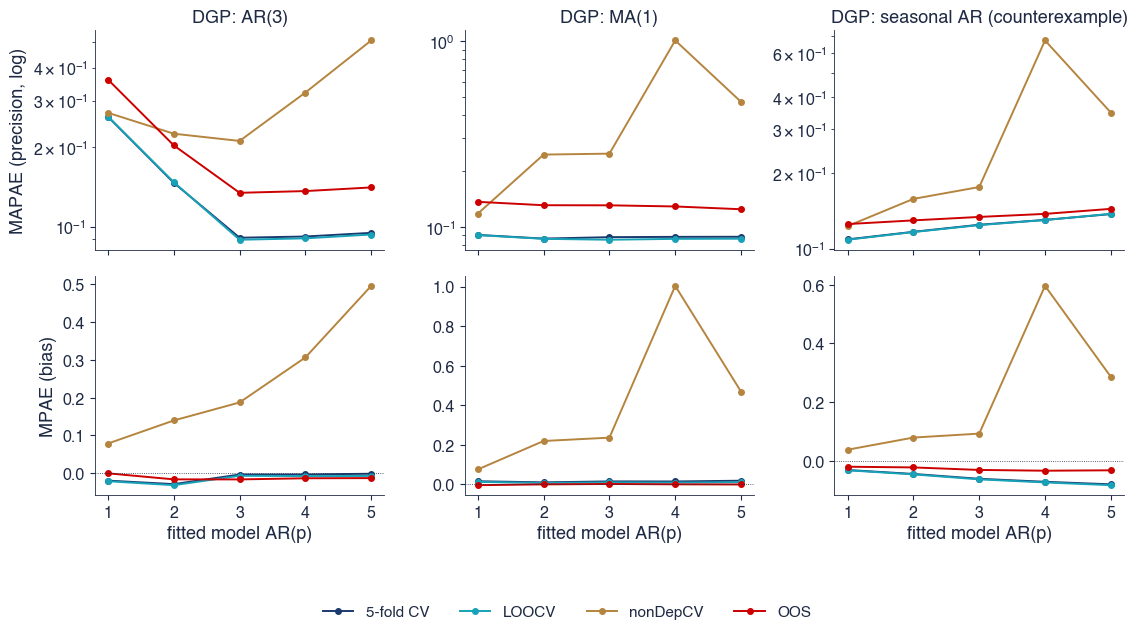

{'AR(3)': {'5-fold CV': {'mapae': 0.09074319111769491, 'mpae': -0.0036086865463783742}, 'OOS': {'mapae': 0.13424936477987742, 'mpae': -0.016562381235295652}}, 'MA(1)': {'5-fold CV': {'mapae': 0.08794076117242962, 'mpae': 0.01473150272944451}, 'OOS': {'mapae': 0.13054018560582478, 'mpae': 0.0017582892465227995}}, 'SAR': {'5-fold CV': {'mapae': 0.12457491070205297, 'mpae': -0.061706191214923864}, 'OOS': {'mapae': 0.13383367508448177, 'mpae': -0.03147831005582325}}}


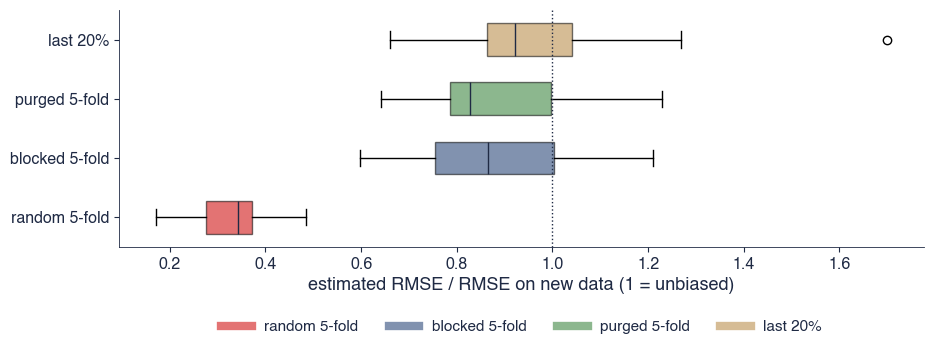

{'random 5-fold': {'med': 0.3419060235705841, 'q1': 0.2745763353810121, 'q3': 0.3714658406196893}, 'blocked 5-fold': {'med': 0.8644448901661532, 'q1': 0.754878011741203, 'q3': 1.0037129494425037}, 'purged 5-fold': {'med': 0.8280903830412162, 'q1': 0.7848362784509912, 'q3': 0.9976432840738103}, 'last 20%': {'med': 0.9225878959701735, 'q1': 0.862429144416142, 'q3': 1.0407411752358502}, 'reps': 8}


In [7]:
def fig_overview(save_it=True):
    """Four data sets of the chapter: Romanian load, EU inflation, S&P 500 realised variance, M4 hourly series."""
    Y = ro_load_hourly()
    P = eu_hicp()
    rv = omi('.SPX')
    train, test, ids = m4_hourly()
    fig, axs = plt.subplots(2, 2, figsize=(11, 6.2))
    daily = Y.mean(axis=1)
    axs[0, 0].plot(daily.index, daily.values, color=st.MainBlue, lw=0.8, label='Romanian load, daily mean (GW)')
    axs[0, 0].set_ylabel('GW')
    import matplotlib.dates as mdates
    axs[0, 0].xaxis.set_major_locator(mdates.YearLocator())
    axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    for c in EU27:
        if c != 'RO':
            axs[0, 1].plot(P.index, P[c], color=st.Teal, lw=0.4, alpha=0.5, label='_')
    axs[0, 1].plot(P.index, P['RO'], color=st.IDAred, lw=1.4, label='Romania')
    axs[0, 1].plot([], [], color=st.Teal, lw=1, label='other EU countries')
    axs[0, 1].set_ylabel('HICP inflation, % y/y')
    axs[1, 0].semilogy(rv.index, rv.values, color=st.Forest, lw=0.5, label='S&P 500 realised variance (%$^2$)')
    for i, c in zip((0, 100, 300), (st.Purple, st.Orange, st.Amber)):
        s = train[i][-24 * 14:]
        axs[1, 1].plot(np.arange(len(s)), s / s.mean(), color=c, lw=0.9, label=f'M4 {ids[i]}')
    axs[1, 1].set_xlabel('hour (last two weeks of the training part)')
    axs[1, 1].set_ylabel('level / mean')
    for a in axs.ravel()[:3]:
        st.legend_outside_bottom(a, ncol=2, y=-0.14)
    st.legend_outside_bottom(axs[1, 1], ncol=3, y=-0.28)
    plt.tight_layout()
    save('ats_ch12_overview', save_it)
    return dict(load_days=int(len(Y)), load_start=str(Y.index[0].date()), load_end=str(Y.index[-1].date()),
                hicp_start=str(P.index[0].date()), hicp_end=str(P.index[-1].date()), hicp_n=int(len(P)),
                rv_n=int(len(rv)), rv_start=str(rv.index[0].date()), rv_end=str(rv.index[-1].date()),
                m4_n=len(train), m4_min=int(min(map(len, train))), m4_max=int(max(map(len, train))),
                load_mean=float(Y.values.mean()), load_min=float(Y.values.min()), load_max=float(Y.values.max()))


def usaccdeaths_sar():
    """Seasonal AR(1)(1)_12 fitted to the monthly US accidental deaths 1973-1978 (Brockwell and Davis 1991), the
    counterexample DGP of Bergmeir, Hyndman and Koo (2018): returns (phi, Phi, sigma) on the standardised series."""
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    u = pd.read_csv(io.BytesIO(get_bytes('https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USAccDeaths.csv')))
    x = u.iloc[:, -1].values.astype(float)
    z = (x - x.mean()) / x.std()
    r = SARIMAX(z, order=(1, 0, 0), seasonal_order=(1, 0, 0, 12), trend='c').fit(disp=False)
    return float(r.params[1]), float(r.params[2]), float(np.sqrt(r.params[3]))


def cv_experiment(reps=1000, n=200, seed=SEED):
    """Bergmeir, Hyndman and Koo (2018, Section 4): 1000 series of length 200 per DGP (stationary AR(3) with random
    coefficients, invertible MA(1) with random coefficient, the seasonal AR fitted to USAccDeaths); MAPAE and MPAE of
    the RMSE estimates of each procedure against the out-set RMSE."""
    rng = np.random.default_rng(seed)
    phi1, Phi, sg = usaccdeaths_sar()
    sar = np.zeros(13)
    sar[0], sar[11], sar[12] = phi1, Phi, -phi1 * Phi
    out = {}
    for dgp in ('AR(3)', 'MA(1)', 'SAR'):
        recs = []
        for r in range(reps):
            if dgp == 'AR(3)':
                y = ar_sim(random_stationary_ar(3, rng), n, rng=rng)
            elif dgp == 'MA(1)':
                y = ar_sim([], n, rng=rng, theta=[rng.uniform(-1, 1)])
            else:
                y = ar_sim(sar, n, burn=200, rng=rng, sigma=sg)
            recs.append(bhk_trial(y, rng=rng))
        res = {}
        for mdl in recs[0]:
            res[mdl] = {}
            for pr in ('5-fold CV', 'LOOCV', 'nonDepCV', 'OOS'):
                e = np.array([rr[mdl][pr] - rr[mdl]['true'] for rr in recs])
                res[mdl][pr] = dict(mapae=float(np.mean(np.abs(e))), mpae=float(np.mean(e)))
        out[dgp] = res
    out['sar_par'] = [phi1, Phi, sg]
    out['reps'] = reps
    return out


def fig_cv_bhk(save_it=True, reps=1000):
    r = cv_experiment(reps)
    fig, axs = plt.subplots(2, 3, figsize=(11.5, 6.0), sharex=True)
    cols = {'5-fold CV': st.MainBlue, 'LOOCV': st.Teal, 'nonDepCV': st.Amber, 'OOS': st.IDAred}
    p = np.arange(1, 6)
    for j, dgp in enumerate(('AR(3)', 'MA(1)', 'SAR')):
        for pr, c in cols.items():
            axs[0, j].plot(p, [r[dgp][f'AR({k})'][pr]['mapae'] for k in p], 'o-', color=c, label=pr, ms=4)
            axs[1, j].plot(p, [r[dgp][f'AR({k})'][pr]['mpae'] for k in p], 'o-', color=c, label=pr, ms=4)
        axs[1, j].axhline(0, color=st.DarkText, lw=0.6, ls=':')
        axs[0, j].set_title({'AR(3)': 'DGP: AR(3)', 'MA(1)': 'DGP: MA(1)', 'SAR': 'DGP: seasonal AR (counterexample)'}[dgp])
        axs[1, j].set_xlabel('fitted model AR(p)')
    for a in axs[0]:
        a.set_yscale('log')
    axs[0, 0].set_ylabel('MAPAE (precision, log)')
    axs[1, 0].set_ylabel('MPAE (bias)')
    plt.tight_layout()
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.subplots_adjust(bottom=0.16)
    save('ats_ch12_cv_bhk', save_it)
    return r


def leakage_experiment(reps=60, n=1000, h=20, phi=0.9, k=5, seed=SEED):
    """Overlapping targets: y_t AR(1); target = mean of y_{t+1..t+h}; features = y_t..y_{t-4} and the time index (a
    typical 'date' feature); random forest.
    Estimated RMSE from random 5-fold, blocked 5-fold, blocked 5-fold with a purge of h rows, the last 20%, against
    the RMSE on 1000 new observations from the same process."""
    from sklearn.ensemble import RandomForestRegressor
    rng = np.random.default_rng(seed)
    rows = []
    for r in range(reps):
        y = ar_sim([phi], 2 * n + 2 * h + 10, rng=rng)
        c = np.concatenate([[0.0], np.cumsum(y)])
        t = np.arange(4, len(y) - h)
        X = np.column_stack([y[t - k] for k in range(5)] + [t])          # y_t, ..., y_{t-4} and a time index
        z = (c[t + h + 1] - c[t + 1]) / h                               # mean of y_{t+1}, ..., y_{t+h}
        Xi, zi, Xo, zo = X[:n], z[:n], X[n + h:], z[n + h:]
        rf = lambda: RandomForestRegressor(n_estimators=50, min_samples_leaf=1, max_features=1.0, random_state=r, n_jobs=1)
        est = {}
        e = np.empty(n)
        f = np.random.default_rng(r).permutation(np.arange(n) % k)
        for j in range(k):
            m = rf().fit(Xi[f != j], zi[f != j])
            e[f == j] = zi[f == j] - m.predict(Xi[f == j])
        est['random 5-fold'] = np.sqrt(np.mean(e ** 2))
        for name, gap in (('blocked 5-fold', 0), ('purged 5-fold', h)):
            e = np.empty(n)
            for tr, te in purged_folds(n, k, gap):
                m = rf().fit(Xi[tr], zi[tr])
                e[te] = zi[te] - m.predict(Xi[te])
            est[name] = np.sqrt(np.mean(e ** 2))
        no = int(0.2 * n)
        m = rf().fit(Xi[:n - no - h], zi[:n - no - h])
        est['last 20%'] = np.sqrt(np.mean((zi[n - no:] - m.predict(Xi[n - no:])) ** 2))
        m = rf().fit(Xi, zi)
        true = np.sqrt(np.mean((zo - m.predict(Xo)) ** 2))
        rows.append({kk: v / true for kk, v in est.items()})
    return pd.DataFrame(rows)


def fig_leakage(save_it=True, reps=60):
    d = leakage_experiment(reps)
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    cols = [st.IDAred, st.MainBlue, st.Forest, st.Amber]
    b = ax.boxplot([d[c] for c in d.columns], vert=False, patch_artist=True, widths=0.55)
    for patch, c in zip(b['boxes'], cols):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    for med in b['medians']:
        med.set_color(st.DarkText)
    ax.set_yticks(range(1, len(d.columns) + 1))
    ax.set_yticklabels(d.columns)
    ax.axvline(1, color=st.DarkText, ls=':', lw=1)
    ax.set_xlabel('estimated RMSE / RMSE on new data (1 = unbiased)')
    for c, lab in zip(cols, d.columns):
        ax.plot([], [], color=c, lw=6, alpha=0.55, label=lab)
    st.legend_outside_bottom(ax, ncol=4, y=-0.25)
    plt.tight_layout()
    save('ats_ch12_leakage', save_it)
    return {c: dict(med=float(d[c].median()), q1=float(d[c].quantile(0.25)), q3=float(d[c].quantile(0.75))) for c in d.columns} | {'reps': reps}


print(fig_overview(save_it=False))
r = fig_cv_bhk(save_it=False, reps=200)
print({d: {p: r[d]['AR(3)'][p] for p in ('5-fold CV', 'OOS')} for d in ('AR(3)', 'MA(1)', 'SAR')})
print(fig_leakage(save_it=False, reps=8))

## 2. Global and local models; the panel lasso

- The lasso is refitted every 12 months here (every 3 months on the slides).

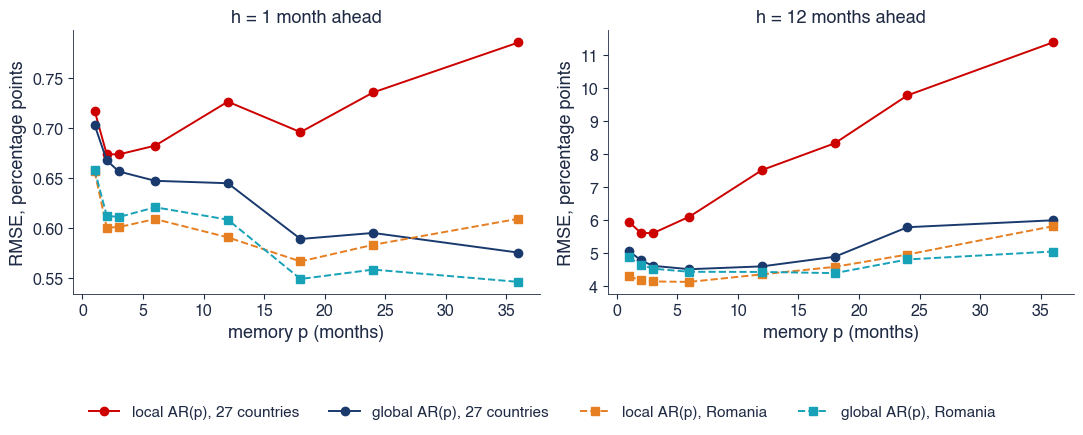

{'1': (3, 36, -4.4), '12': (3, 6, -1.09)}


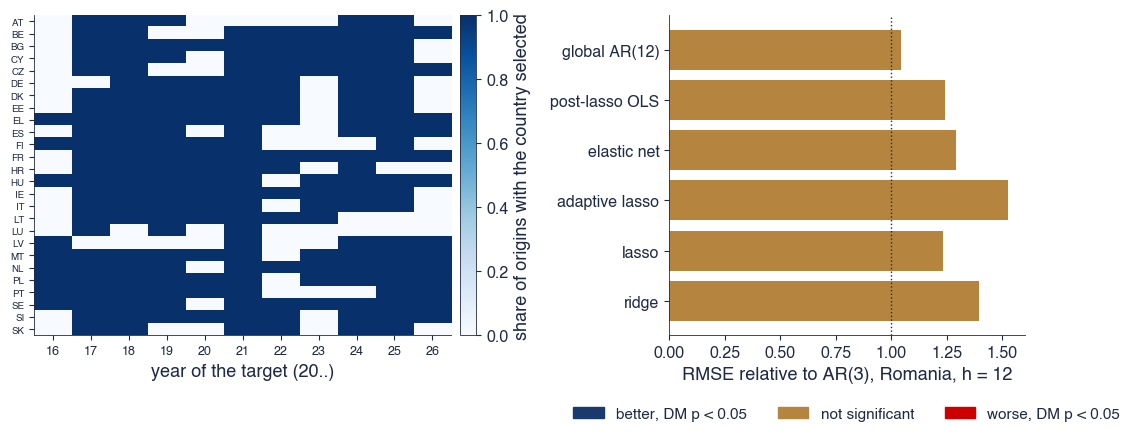

{'AR(3)': 4.24123982703594, 'ridge': 5.914386770771632, 'lasso': 5.226534636834687, 'adaptive lasso': 6.4630505582107265, 'elastic net': 5.483104734728555, 'post-lasso OLS': 5.273417970722065, 'global AR(12)': 4.419246260617888}


In [8]:
def lagmat(x, p):
    """Columns x_t, x_{t-1}, ..., x_{t-p+1} (NaN at the start)."""
    return np.column_stack([np.r_[np.full(k, np.nan), x[:len(x) - k]] for k in range(p)])


def global_local(h=12, lags=INFL['lags'], win=INFL['win'], first=INFL['first']):
    """Direct h-step forecasts of annual HICP inflation of the 27 EU countries from rolling windows of `win` months:
    local AR(p) (one OLS per country) against global AR(p) (one pooled OLS, the same coefficients for all
    countries; Montero-Manso and Hyndman 2021). Returns squared errors: dict p -> (local, global), each origins x 27."""
    P = eu_hicp()
    Y = P.values
    T, N = Y.shape
    dates = P.index
    o0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    out = {}
    for p in lags:
        L = [lagmat(Y[:, i], p) for i in range(N)]
        el, eg = [], []
        for t in range(o0, T - h):
            rows = np.arange(max(t - win + 1, p - 1), t - h + 1)       # targets y_{s+h} known at t
            Xg, yg = [], []
            fl, fg = np.empty(N), np.empty(N)
            for i in range(N):
                X, y = L[i][rows], Y[rows + h, i]
                fl[i] = ols(X, y, L[i][t:t + 1])[0]
                Xg.append(X)
                yg.append(y)
            Xg, yg = np.vstack(Xg), np.concatenate(yg)
            for i in range(N):
                fg[i] = ols(Xg, yg, L[i][t:t + 1])[0]
            el.append((Y[t + h] - fl) ** 2)
            eg.append((Y[t + h] - fg) ** 2)
        out[p] = (np.array(el), np.array(eg))
    return out, list(P.columns)


def fig_global_local(save_it=True, lags=INFL['lags']):
    res = {}
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.0))
    for ax, h in zip(axs, (1, 12)):
        r, cn = global_local(h, lags)
        ro = cn.index('RO')
        loc = [np.sqrt(r[p][0].mean()) for p in lags]
        glo = [np.sqrt(r[p][1].mean()) for p in lags]
        lro = [np.sqrt(r[p][0][:, ro].mean()) for p in lags]
        gro = [np.sqrt(r[p][1][:, ro].mean()) for p in lags]
        ax.plot(lags, loc, 'o-', color=st.IDAred, label='local AR(p), 27 countries')
        ax.plot(lags, glo, 'o-', color=st.MainBlue, label='global AR(p), 27 countries')
        ax.plot(lags, lro, 's--', color=st.Orange, label='local AR(p), Romania')
        ax.plot(lags, gro, 's--', color=st.Teal, label='global AR(p), Romania')
        ax.set_xlabel('memory p (months)')
        ax.set_ylabel('RMSE, percentage points')
        ax.set_title(f'h = {h} month' + ('s' if h > 1 else '') + ' ahead')
        best_l, best_g = int(lags[int(np.argmin(loc))]), int(lags[int(np.argmin(glo))])
        dg = r[best_g][1][:, ro] - r[best_l][0][:, ro]
        dm = dm_test(dg, h)
        dall = (r[best_g][1] - r[best_l][0]).mean(axis=1)
        res[str(h)] = dict(local=loc, glob=glo, local_ro=lro, glob_ro=gro, best_l=best_l, best_g=best_g,
                           dm_ro=dm['hln'], p_ro=dm['p_hln'], dm_all=dm_test(dall, h)['hln'], p_all=dm_test(dall, h)['p_hln'],
                           T=int(r[lags[0]][0].shape[0]))
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch12_global_local', save_it)
    res['lags'] = list(lags)
    return res


def ols_coef(X, y):
    """OLS coefficients with an intercept (first)."""
    A = np.column_stack([np.ones(len(X)), X])
    return np.linalg.lstsq(A, y, rcond=None)[0]


def ro_highdim(h=12, win=INFL['win'], first=INFL['first'], p=INFL['x_lags'], refit=3):
    """Romanian inflation h months ahead from the EU panel on rolling windows of `win` months, re-estimated every
    `refit` months: AR(3) (local benchmark); ridge, lasso, adaptive lasso and elastic net on the 3 own lags (not
    penalised) plus 3 lags of the 26 other countries (78 penalised features; penalty by blocked CV with a purge of h
    months); post-lasso OLS; the global AR(12) of the panel."""
    from sklearn.linear_model import Ridge
    P = eu_hicp()
    Y = P.values
    T, N = Y.shape
    cn = list(P.columns)
    ro = cn.index('RO')
    others = [i for i in range(N) if i != ro]
    Z = np.column_stack([lagmat(Y[:, ro], p)] + [lagmat(Y[:, i], p) for i in others])   # own lags first
    own = list(range(p))
    L12 = [lagmat(Y[:, i], 12) for i in range(N)]
    dates = P.index
    o0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    names = ['AR(3)', 'ridge', 'lasso', 'adaptive lasso', 'elastic net', 'post-lasso OLS', 'global AR(12)']
    F = {k: [] for k in names}
    sel, yv, od = [], [], []
    par = {}
    for t in range(o0, T - h):
        rows = np.arange(max(t - win + 1, 11), t - h + 1)
        X, y, x0 = Z[rows], Y[rows + h, ro], Z[t:t + 1]
        if (t - o0) % refit == 0:
            par = {'AR(3)': ols_coef(X[:, own], y)}
            K = np.column_stack([np.ones(len(y)), X[:, own]])
            Xo = X[:, p:]
            mu, sd = Xo.mean(0), Xo.std(0) + 1e-12
            r = Ridge(alpha=float(len(y))).fit(np.column_stack([X[:, own] * 1e3, (Xo - mu) / sd]), y)   # own lags nearly unpenalised
            par['ridge'] = (r, mu, sd)
            for kind, nm in (('lasso', 'lasso'), ('adaptive', 'adaptive lasso'), ('enet', 'elastic net')):
                a, b, _, s = penalised_fit(X, y, kind, keep=own, gap=h)
                par[nm] = (a, b)
                if kind == 'lasso':
                    par['sel'] = s
                    cols = own + [p + j for j in np.where(s)[0]]
                    par['post-lasso OLS'] = (cols, ols_coef(X[:, cols], y))
            Xg = np.vstack([L12[i][rows] for i in range(N)])
            yg = np.concatenate([Y[rows + h, i] for i in range(N)])
            par['global AR(12)'] = ols_coef(Xg, yg)
        F['AR(3)'].append(np.r_[1.0, x0[0, own]] @ par['AR(3)'])
        r, mu, sd = par['ridge']
        F['ridge'].append(r.predict(np.column_stack([x0[:, own] * 1e3, (x0[:, p:] - mu) / sd]))[0])
        for nm in ('lasso', 'adaptive lasso', 'elastic net'):
            a, b = par[nm]
            F[nm].append(a + x0[0] @ b)
        cols, b = par['post-lasso OLS']
        F['post-lasso OLS'].append(np.r_[1.0, x0[0, cols]] @ b)
        F['global AR(12)'].append(np.r_[1.0, L12[ro][t]] @ par['global AR(12)'])
        sel.append(par['sel'])
        yv.append(Y[t + h, ro])
        od.append(dates[t + h])
    return {k: np.array(v) for k, v in F.items()}, np.array(yv), np.array(sel), od, [cn[i] for i in others]


def fig_ro_lasso(save_it=True, h=12, refit=3):
    F, y, S, od, cn = ro_highdim(h, refit=refit)
    p = INFL['x_lags']
    N = len(cn)                                                          # the 26 other countries
    blocks = S.reshape(len(S), N, p).any(axis=2)                        # a country is selected if any of its lags is
    years = pd.DatetimeIndex(od).year
    yrs = sorted(set(years))
    freq = np.array([blocks[years == yy].mean(axis=0) for yy in yrs]).T
    e = {k: (y - f) ** 2 for k, f in F.items()}
    rmse = {k: float(np.sqrt(v.mean())) for k, v in e.items()}
    dm = {k: dm_test(e[k] - e['AR(3)'], h) for k in F if k != 'AR(3)'}
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={'width_ratios': [1.25, 1]})
    im = axs[0].imshow(freq, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axs[0].set_yticks(range(N))
    axs[0].set_yticklabels(cn, fontsize=7)
    axs[0].set_xticks(range(len(yrs)))
    axs[0].set_xticklabels([str(v)[2:] for v in yrs], fontsize=9)
    axs[0].set_xlabel('year of the target (20..)')
    plt.colorbar(im, ax=axs[0], fraction=0.04, pad=0.02, label='share of origins with the country selected')
    ks = [k for k in F if k != 'AR(3)']
    rel = [rmse[k] / rmse['AR(3)'] for k in ks]
    cols = [st.MainBlue if dm[k]['p_hln'] < 0.05 and r < 1 else st.IDAred if dm[k]['p_hln'] < 0.05 else st.Amber for k, r in zip(ks, rel)]
    axs[1].barh(range(len(ks)), rel, color=cols)
    axs[1].set_yticks(range(len(ks)))
    axs[1].set_yticklabels(ks)
    axs[1].axvline(1, color=st.DarkText, ls=':', lw=1)
    axs[1].set_xlabel('RMSE relative to AR(3), Romania, h = 12')
    from matplotlib.patches import Patch
    hd = [Patch(color=st.MainBlue, label='better, DM p < 0.05'), Patch(color=st.Amber, label='not significant'),
          Patch(color=st.IDAred, label='worse, DM p < 0.05')]
    axs[1].legend(handles=hd, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
    plt.tight_layout()
    save('ats_ch12_ro_lasso', save_it)
    tot = blocks.mean(axis=0)
    top = np.argsort(-tot)[:5]
    return dict(rmse=rmse, dm={k: dict(t=v['hln'], p=v['p_hln']) for k, v in dm.items()}, T=int(len(y)),
                n_sel_med=float(np.median(S.sum(axis=1))), n_sel_min=int(S.sum(axis=1).min()), n_sel_max=int(S.sum(axis=1).max()),
                top=[cn[i] for i in top], top_share=[float(tot[i]) for i in top], never=int((tot == 0).sum()),
                n_feat=int(S.shape[1]), first=str(od[0].date()), last=str(od[-1].date()))


r = fig_global_local(save_it=False)
print({h: (r[h]['best_l'], r[h]['best_g'], round(r[h]['dm_all'], 2)) for h in ('1', '12')})
r = fig_ro_lasso(save_it=False, refit=12)
print(r['rmse'])

## 3. Tree ensembles for Romanian day-ahead load

- 50 trees and quarterly refits here (100 trees and monthly refits on the slides).

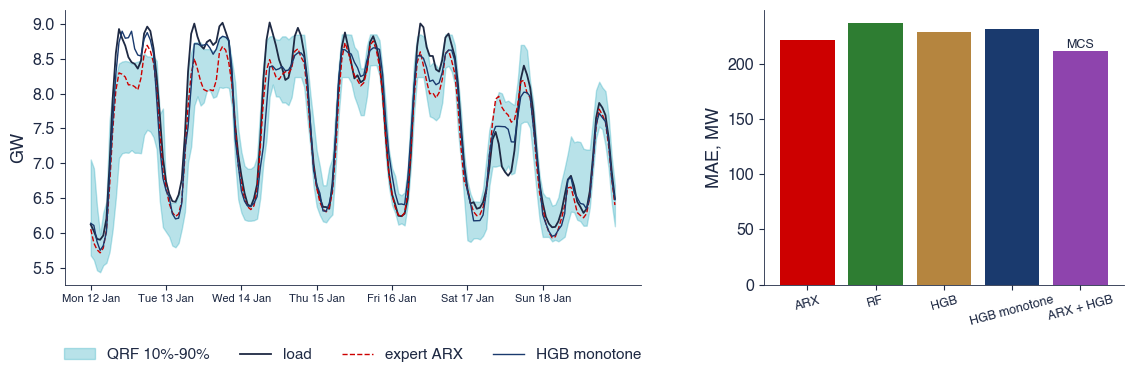

{'ARX': 0.2211965432335945, 'RF': 0.23693189875302778, 'HGB': 0.22884019114476442, 'HGB monotone': 0.23126897647461392, 'ARX + HGB': 0.2120899631638377} {'ARX': 0.0890826225922152, 'QRF': 0.09421239267072062, 'HGB': 0.09145126788248889} {'ARX': 0.7806295715778474, 'QRF': 0.8213819226750261, 'HGB': 0.595807210031348}


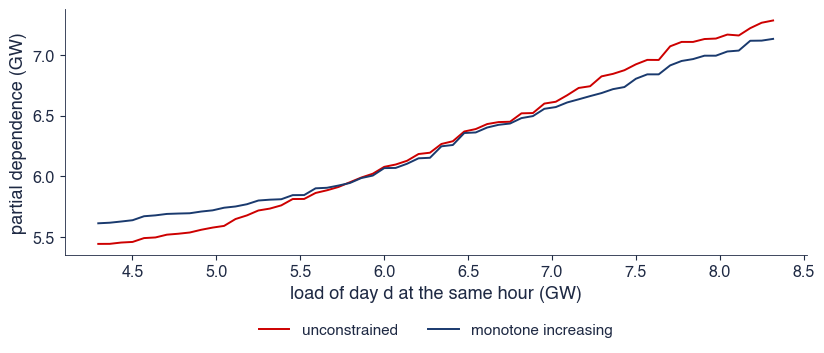

{'unconstrained': {'n_down': 3, 'worst': -0.007470485845199271, 'range': 1.838949113324115}, 'monotone increasing': {'n_down': 0, 'worst': 0.0, 'range': 1.5178230267452157}}


In [9]:
def load_features(Y):
    """Rows (day d+1, hour h) of the day-ahead problem with data up to day d: load at the same hour on days d, d - 1
    and d - 6, the minimum, maximum and last hour of day d, the hour, the day of the week, a holiday dummy, the
    annual cycle. Returns X, y, day index, hour, feature names."""
    A = Y.values
    days = Y.index
    nD = len(days)
    hol = set(ro_holidays(range(days[0].year, days[-1].year + 1)))
    d1 = np.repeat(np.arange(7, nD), 24)
    hh = np.tile(np.arange(24), nD - 7)
    doy = np.array([days[i].dayofyear for i in d1])
    dow = np.array([days[i].dayofweek for i in d1])
    X = np.column_stack([A[d1 - 1, hh], A[d1 - 2, hh], A[d1 - 7, hh], A[d1 - 1].min(1), A[d1 - 1].max(1), A[d1 - 1, 23],
                         hh, dow, [days[i] in hol for i in d1], [days[i - 1] in hol for i in d1],
                         np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)]).astype(float)
    names = ['load d', 'load d-1', 'load d-6', 'min d', 'max d', 'last hour d', 'hour', 'weekday', 'holiday',
             'holiday d', 'sin year', 'cos year']
    return X, A[d1, hh], d1, hh, names


def load_tree_forecasts(first=LOAD_EVAL, refit='MS', n_trees=100):
    """Day-ahead forecasts of the 24 hourly loads from `first` to LOAD_END, re-estimated at the start of each month on
    all earlier data: the expert ARX of Chapter 1 (Ziel and Weron 2018; one regression per hour, 364-day window,
    empirical quantiles of the last 182 days of errors), a random forest with QRF quantiles, boosting (HGB) with and
    without monotone constraints and HGB quantile regressions (deciles). Returns a long DataFrame."""
    from sklearn.ensemble import HistGradientBoostingRegressor as HGB
    Y = ro_load_hourly()
    X, y, d1, hh, names = load_features(Y)
    days = Y.index
    A = Y.values
    dates = days[d1]
    starts = pd.date_range(first, LOAD_END, freq=refit)
    out = []
    for k, s in enumerate(starts):
        e = starts[k + 1] if k + 1 < len(starts) else pd.Timestamp(LOAD_END) + pd.Timedelta(days=1)
        tr = dates < s
        te = (dates >= s) & (dates < e)
        res = dict(day=dates[te], hour=hh[te], y=y[te])
        hgb = lambda **kw: HGB(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=40,
                               random_state=SEED, categorical_features=[6, 7], **kw)
        res['HGB'] = hgb().fit(X[tr], y[tr]).predict(X[te])
        res['HGB monotone'] = hgb(monotonic_cst=MONO).fit(X[tr], y[tr]).predict(X[te])
        for tau in TAUS9:
            res[f'HGBq{tau:.1f}'] = hgb(loss='quantile', quantile=tau).fit(X[tr], y[tr]).predict(X[te])
        q = QRF(n_estimators=n_trees, min_samples_leaf=10, max_features=0.5, seed=SEED).fit(X[tr], y[tr])
        res['RF'] = q.predict(X[te])
        Q = q.quantiles(X[te], TAUS9)
        for j, tau in enumerate(TAUS9):
            res[f'QRFq{tau:.1f}'] = Q[:, j]
        out.append(pd.DataFrame(res))
    D = pd.concat(out, ignore_index=True)
    # expert ARX (Chapter 1): rolling 364-day window, one regression per hour, refitted every day
    dow = np.array([d.dayofweek for d in days])
    mins, maxs, last = A.min(axis=1), A.max(axis=1), A[:, 23]
    s0 = int(np.searchsorted(days, pd.Timestamp(first)))
    P = np.full(A.shape, np.nan)
    for dd in range(s0 - 182, len(days)):
        rows = np.arange(dd - 364, dd)
        for h in range(24):
            Xa = np.column_stack([np.ones(len(rows)), A[rows - 1, h], A[rows - 2, h], A[rows - 7, h], mins[rows - 1],
                                  maxs[rows - 1], last[rows - 1], dow[rows] == 0, dow[rows] == 5, dow[rows] == 6])
            b = np.linalg.lstsq(Xa, A[rows, h], rcond=None)[0]
            P[dd, h] = np.r_[1.0, A[dd - 1, h], A[dd - 2, h], A[dd - 7, h], mins[dd - 1], maxs[dd - 1], last[dd - 1],
                             dow[dd] == 0, dow[dd] == 5, dow[dd] == 6] @ b
    E = A - P
    di = np.searchsorted(days, D['day'].values)
    D['ARX'] = P[di, D['hour'].values]
    D['ARX + HGB'] = 0.5 * (D['ARX'] + D['HGB monotone'])                  # equal-weight combination (Chapter 1)
    QA = np.array([[P[dd, h] + np.nanquantile(E[dd - 182:dd, h], TAUS9) for h in range(24)] for dd in range(s0, len(days))])
    for j, tau in enumerate(TAUS9):
        D[f'ARXq{tau:.1f}'] = QA[di - s0, D['hour'].values, j]
    return D


def fig_load_trees(save_it=True, n_trees=100, refit='MS'):
    D = load_tree_forecasts(refit=refit, n_trees=n_trees)
    D = D.sort_values(['day', 'hour']).reset_index(drop=True)
    pts = ['ARX', 'RF', 'HGB', 'HGB monotone', 'ARX + HGB']
    mae = {k: float(np.mean(np.abs(D['y'] - D[k]))) for k in pts}
    daily = pd.DataFrame({k: np.abs(D['y'] - D[k]).groupby(D['day']).mean() for k in pts})
    M = mcs(daily)
    dmv = {k: dm_test(daily[k] - daily['ARX'], 1) for k in pts if k != 'ARX'}
    pin, cov = {}, {}
    for k in ('ARX', 'QRF', 'HGB'):
        L = np.mean([pinball(D['y'], D[f'{k}q{t:.1f}'], t) for t in TAUS9], axis=0)
        pin[k] = float(L.mean())
        cov[k] = float(np.mean((D['y'] >= D[f'{k}q0.1']) & (D['y'] <= D[f'{k}q0.9'])))
        D[f'pin_{k}'] = L
    dpin = pd.DataFrame({k: D[f'pin_{k}'].groupby(D['day']).mean() for k in ('ARX', 'QRF', 'HGB')})
    Mq = mcs(dpin)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={'width_ratios': [1.6, 1]})
    wk = D[(D['day'] >= '2026-01-12') & (D['day'] < '2026-01-19')]
    x = np.arange(len(wk))
    axs[0].fill_between(x, wk['QRFq0.1'], wk['QRFq0.9'], color=st.Teal, alpha=0.3, label='QRF 10%-90%')
    axs[0].plot(x, wk['y'], color=st.DarkText, lw=1.3, label='load')
    axs[0].plot(x, wk['ARX'], color=st.IDAred, lw=1, ls='--', label='expert ARX')
    axs[0].plot(x, wk['HGB monotone'], color=st.MainBlue, lw=1, label='HGB monotone')
    axs[0].set_xticks(np.arange(0, len(wk), 24))
    axs[0].set_xticklabels([d.strftime('%a %d %b') for d in wk['day'].iloc[::24]], fontsize=8)
    axs[0].set_ylabel('GW')
    st.legend_outside_bottom(axs[0], ncol=4, y=-0.18)
    ks = pts
    axs[1].bar(range(len(ks)), [1000 * mae[k] for k in ks], color=[st.IDAred, st.Forest, st.Amber, st.MainBlue, st.Purple])
    for i, k in enumerate(ks):
        axs[1].text(i, 1000 * mae[k], 'MCS' if k in M['set'] else '', ha='center', va='bottom', fontsize=9, color=st.DarkText)
    axs[1].set_xticks(range(len(ks)))
    axs[1].set_xticklabels(ks, rotation=15, fontsize=9)
    axs[1].set_ylabel('MAE, MW')
    plt.tight_layout()
    save('ats_ch12_load_trees', save_it)
    return dict(mae=mae, mcs=M['p'], dm={k: dict(t=v['hln'], p=v['p_hln']) for k, v in dmv.items()}, pin=pin, cov=cov,
                mcs_q=Mq['p'], days=int(D['day'].nunique()), first=str(D['day'].min().date()), last=str(D['day'].max().date()))


def fig_monotone(save_it=True):
    """Partial dependence of boosted trees on the load of day d at the same hour, with and without the monotone
    constraint, trained on all data before LOAD_EVAL."""
    from sklearn.ensemble import HistGradientBoostingRegressor as HGB
    Y = ro_load_hourly()
    X, y, d1, hh, names = load_features(Y)
    tr = Y.index[d1] < pd.Timestamp(LOAD_EVAL)
    grid = np.linspace(np.quantile(X[tr, 0], 0.01), np.quantile(X[tr, 0], 0.99), 60)
    ref = X[tr][::25]
    out = {}
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for lab, kw, c in (('unconstrained', {}, st.IDAred), ('monotone increasing', {'monotonic_cst': MONO}, st.MainBlue)):
        m = HGB(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=40, random_state=SEED,
                categorical_features=[6, 7], **kw).fit(X[tr], y[tr])
        pd_ = []
        for g in grid:
            Z = ref.copy()
            Z[:, 0] = g
            pd_.append(m.predict(Z).mean())
        pd_ = np.array(pd_)
        ax.plot(grid, pd_, color=c, label=lab)
        dif = np.diff(pd_)
        out[lab] = dict(n_down=int((dif < -1e-6).sum()), worst=float(dif.min()), range=float(pd_[-1] - pd_[0]))
    ax.set_xlabel('load of day d at the same hour (GW)')
    ax.set_ylabel('partial dependence (GW)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save('ats_ch12_monotone', save_it)
    return out


r = fig_load_trees(save_it=False, n_trees=50, refit='QS')
print(r['mae'], r['pin'], r['cov'])
print(fig_monotone(save_it=False))

## 4. Recurrent networks: gradients through time; deep models against HAR

- Horizons 1 and 22 and 30 epochs here.

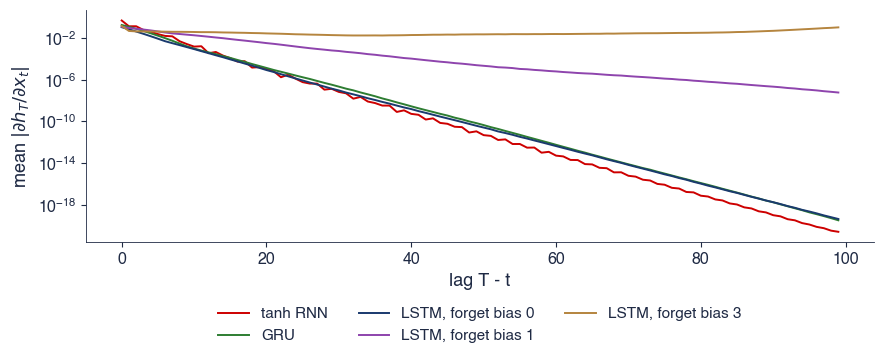

{'rnn': 3.70979150177142e-11, 'gru': 3.8176950489798855e-10, 'lstm': 3.872696052731328e-10, 'lstm_b1': 0.00023723667254671454, 'lstm_b3': 0.4718870222568512}


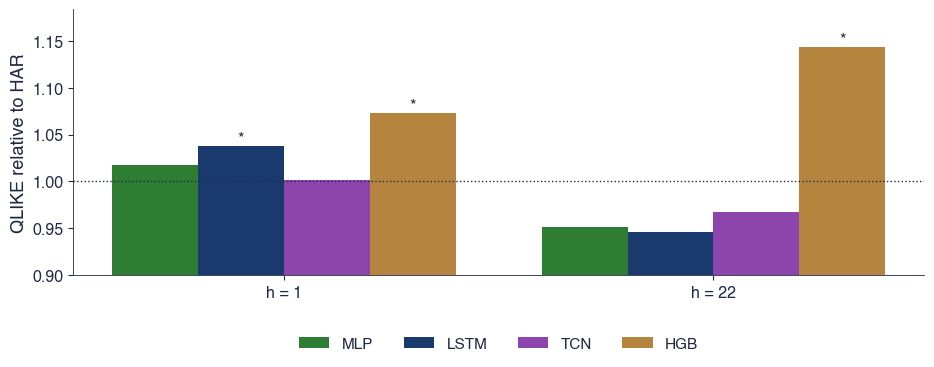

{'1': {'HAR': 1.0, 'MLP': 1.0180138752758954, 'LSTM': 1.0380770697537725, 'TCN': 1.0015986245945165, 'HGB': 1.0735630478096896}, '22': {'HAR': 1.0, 'MLP': 0.951221448024326, 'LSTM': 0.9464006640296535, 'TCN': 0.9679504739096947, 'HGB': 1.143817885390613}}


In [10]:
def fig_vanishing(save_it=True, T=100, seeds=5):
    """Gradients through time at initialisation: tanh RNN, GRU, LSTM with the default forget-gate bias 0, and LSTM
    with forget-gate bias 1 and 3 (Gers, Schmidhuber and Cummins 2000; Jozefowicz, Zaremba and Sutskever 2015)."""
    spec = {'rnn': ('rnn', None), 'gru': ('gru', None), 'lstm': ('lstm', None), 'lstm_b1': ('lstm', 1.0), 'lstm_b3': ('lstm', 3.0)}
    G = {k: np.mean([grad_through_time(c, T, seed=s, forget_bias=b) for s in range(seeds)], axis=0) for k, (c, b) in spec.items()}
    fig, ax = plt.subplots(figsize=(9, 3.9))
    lag = T - np.arange(1, T + 1)
    for k, c, lab in (('rnn', st.IDAred, 'tanh RNN'), ('gru', st.Forest, 'GRU'), ('lstm', st.MainBlue, 'LSTM, forget bias 0'),
                      ('lstm_b1', st.Purple, 'LSTM, forget bias 1'), ('lstm_b3', st.Amber, 'LSTM, forget bias 3')):
        ax.semilogy(lag, G[k], color=c, label=lab)
    ax.set_xlabel('lag T - t')
    ax.set_ylabel(r'mean $|\partial h_T / \partial x_t|$')
    st.legend_outside_bottom(ax, ncol=3, y=-0.22)
    plt.tight_layout()
    save('ats_ch12_vanishing', save_it)
    out = {}
    for k, g in G.items():
        r = g[::-1]                                                     # r[j]: lag j
        out[k] = dict(g1=float(r[1]), g10=float(r[10]), g50=float(r[50]), ratio50=float(r[50] / r[1]),
                      rate=float(-np.polyfit(np.arange(1, 41), np.log(r[1:41]), 1)[0]))
    out['T'], out['seeds'] = T, seeds
    return out


def rv_windows(y, L):
    """Rows t = L-1..n-1: X[t] = (y_{t-L+1}, ..., y_t) (oldest first)."""
    return np.lib.stride_tricks.sliding_window_view(y, L)


def har_feats(W):
    """HAR regressors from windows of 22 values (oldest first): daily, weekly and monthly means."""
    return np.column_stack([W[:, -1], W[:, -5:].mean(1), W.mean(1)])


def rv_forecasts(rv, models=('HAR', 'MLP', 'LSTM', 'TCN', 'HGB'), horizons=RV['horizons'], first=RV['first'],
                 refit=RV['refit'], seeds=(0,), epochs=60):
    """Expanding-window forecasts of RV_{t+h} (one day, h ahead) from y = log RV: HAR (OLS on the daily, weekly,
    monthly means), an MLP and an LSTM and a TCN on the last 22 values (standardised with the training mean and
    standard deviation; average of the seeds), boosting on the 22 lags. Level forecast exp(m + s^2/2), s^2 the
    training residual variance. Re-estimation every `refit` days from day `first`."""
    from sklearn.ensemble import HistGradientBoostingRegressor as HGB
    y = np.log(np.asarray(rv, float))
    L = RV['lags']
    W = rv_windows(y, L)
    tw = np.arange(L - 1, len(y))                                       # time of the last value of each window
    out = {}
    for h in horizons:
        ok = tw + h < len(y)
        Wh, th = W[ok], tw[ok]
        target = y[th + h]
        rec = {k: np.full(len(th), np.nan) for k in models}
        for o in range(first, len(y) - h, refit):
            tr = th + h <= o                                            # targets known at the origin o
            te = (th >= o) & (th < o + refit)
            if not te.any():
                continue
            mu, sd = Wh[tr].mean(), Wh[tr].std()
            Xtr, Xte, ytr = (Wh[tr] - mu) / sd, (Wh[te] - mu) / sd, (target[tr] - mu) / sd
            for k in models:
                if k == 'HAR':
                    A = har_feats(Wh[tr])
                    b = np.linalg.lstsq(np.column_stack([np.ones(len(A)), A]), target[tr], rcond=None)[0]
                    fi = np.column_stack([np.ones(len(A)), A]) @ b
                    f = np.column_stack([np.ones(te.sum()), har_feats(Wh[te])]) @ b
                    s2 = np.var(target[tr] - fi)
                elif k == 'HGB':
                    m = HGB(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=50, random_state=SEED)
                    m.fit(Xtr, ytr)
                    f = mu + sd * m.predict(Xte)
                    s2 = np.var(sd * (ytr - m.predict(Xtr)))
                elif TORCH:
                    fs, ss = [], []
                    for s in seeds:
                        net = {'MLP': lambda: MLPNet(L, 1, 32, 2), 'LSTM': lambda: RNNNet(1, 16, 'lstm'),
                               'TCN': lambda: TCNNet(1, 16, 3, 3)}[k]()
                        net = fit_torch(net, Xtr, ytr[:, None], epochs=epochs, lr=2e-3, batch=128, seed=s)
                        fs.append(mu + sd * predict_torch(net, Xte)[:, 0])
                        ss.append(np.var(sd * (ytr - predict_torch(net, Xtr)[:, 0])))
                    f, s2 = np.mean(fs, 0), np.mean(ss)
                else:
                    continue
                rec[k][te] = np.exp(f + s2 / 2)
        keep = ~np.isnan(rec[models[0]])
        out[h] = pd.DataFrame({'t': th[keep], 'rv': np.exp(target[keep]), **{k: v[keep] for k, v in rec.items()}})
    return out


def evaluate_rv(F, base='HAR'):
    """QLIKE of each model, ratio to the base, DM (HLN) statistics against the base and the MCS p-values."""
    out = {}
    for h, d in F.items():
        ms = [c for c in d.columns if c not in ('t', 'rv')]
        Lq = pd.DataFrame({k: qlike(d['rv'], d[k]) for k in ms})
        e = {'T': int(len(d)), 'qlike': {k: float(Lq[k].mean()) for k in ms}}
        e['rel'] = {k: e['qlike'][k] / e['qlike'][base] for k in ms}
        e['dm'] = {k: dm_test(Lq[k] - Lq[base], h) for k in ms if k != base}
        e['mcs'] = mcs(Lq, block=max(h, 5))['p']
        out[str(h)] = e
    return out


def fig_rv_deep(save_it=True, horizons=RV['horizons'], epochs=60):
    rv = omi('.SPX')
    F = rv_forecasts(rv, horizons=horizons, epochs=epochs)
    E = evaluate_rv(F)
    ms = ['MLP', 'LSTM', 'TCN', 'HGB']
    fig, ax = plt.subplots(figsize=(9.5, 3.9))
    w = 0.2
    cols = [st.Forest, st.MainBlue, st.Purple, st.Amber]
    for j, (k, c) in enumerate(zip(ms, cols)):
        vals = [E[str(h)]['rel'][k] for h in horizons]
        ax.bar(np.arange(len(horizons)) + (j - 1.5) * w, vals, w, color=c, label=k)
        for i, h in enumerate(horizons):
            p = E[str(h)]['dm'][k]['p_hln']
            if p < 0.05:
                ax.text(i + (j - 1.5) * w, vals[i], '*', ha='center', va='bottom', color=st.DarkText)
    ax.axhline(1, color=st.DarkText, ls=':', lw=1)
    ax.set_xticks(range(len(horizons)))
    ax.set_xticklabels([f'h = {h}' for h in horizons])
    ax.set_ylabel('QLIKE relative to HAR')
    lo = min(min(E[str(h)]['rel'][k] for k in ms) for h in horizons)
    hi = max(max(E[str(h)]['rel'][k] for k in ms) for h in horizons)
    ax.set_ylim(min(0.9, lo - 0.03), max(1.1, hi + 0.04))
    st.legend_outside_bottom(ax, ncol=4, y=-0.18)
    plt.tight_layout()
    save('ats_ch12_rv_deep', save_it)
    d = F[horizons[0]]
    ev = {}
    for h, e in E.items():
        ev[h] = dict(T=e['T'], qlike=e['qlike'], rel=e['rel'], mcs=e['mcs'],
                     dm={m: dict(t=v['hln'], p=v['p_hln']) for m, v in e['dm'].items()})
    return dict(eval=ev, n=int(len(rv)), start=str(rv.index[0].date()), end=str(rv.index[-1].date()),
                oos_start=str(rv.index[int(d['t'].iloc[0])].date()), oos_T=int(len(d)))


r = fig_vanishing(save_it=False)
print({k: v['ratio50'] for k, v in r.items() if isinstance(v, dict)})
r = fig_rv_deep(save_it=False, horizons=(1, 22), epochs=30)
print({h: e['rel'] for h, e in r['eval'].items()})

## 5. Transformers against linear models: the Zeng et al. (2023) protocol

- One seed, horizon 96 and 5 epochs here.

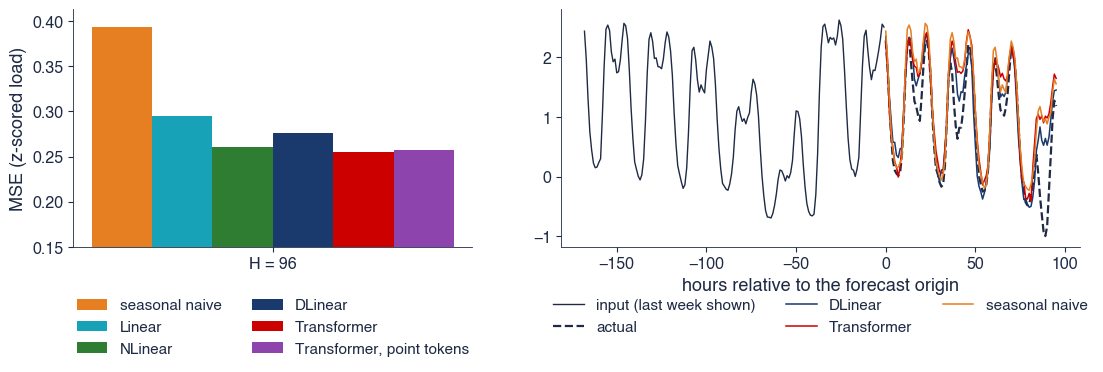

{'96': {'repeat': {'mse': 1.5846490727613374, 'mae': 1.002903393990447}, 'seasonal naive': {'mse': 0.39346223364459654, 'mae': 0.43750963153911215}, 'Linear': {'mse': 0.29436840862930985, 'mae': 0.3950945401789499}, 'NLinear': {'mse': 0.2603095570796805, 'mae': 0.3555525434821354}, 'DLinear': {'mse': 0.27612666639944305, 'mae': 0.3740016700645049}, 'Transformer': {'mse': 0.25558045946222807, 'mae': 0.3596129337292729}, 'Transformer, point tokens': {'mse': 0.25759190835265156, 'mae': 0.36183417972243953}}}


In [11]:
def zeng_data():
    """Romanian hourly load as one series, z-scored with the training mean and standard deviation; 7:1:2 split."""
    Y = ro_load_hourly()
    s = Y.values.ravel()
    n = len(s)
    a, b = int(ZENG['split'][0] * n), int((ZENG['split'][0] + ZENG['split'][1]) * n)
    mu, sd = s[:a].mean(), s[:a].std()
    return (s - mu) / sd, a, b, Y.index[0]


def zeng_windows(z, lo, hi, L, H, stride=1):
    """Windows whose targets lie in [lo, hi): inputs z[t-L:t], targets z[t:t+H]."""
    t = np.arange(max(lo, L), hi - H + 1, stride)
    idx = t[:, None] + np.arange(-L, 0)[None, :]
    jdx = t[:, None] + np.arange(H)[None, :]
    return z[idx], z[jdx]


def zeng_experiment(horizons=ZENG['horizons'], seeds=(0, 1, 2), epochs=20, stride=2):
    """Long-horizon forecasts on the test block: repeat the last value, seasonal naive (last week), Linear, NLinear,
    DLinear (kernel 25), the patch Transformer (patches of 24 hours) and the same Transformer with one token per hour
    (one seed, at most 8 epochs: the cost grows with the square of the number of tokens); MSE and MAE on the z-scored
    series; the networks are trained with Adam (MSE), early stopping on the validation block, seeds averaged."""
    z, a, b, _ = zeng_data()
    L = ZENG['L']
    res, keep = {}, {}
    for H in horizons:
        Xtr, Ytr = zeng_windows(z, 0, a, L, H, stride)
        Xva, Yva = zeng_windows(z, a, b, L, H, 1)
        Xte, Yte = zeng_windows(z, b, len(z), L, H, 1)
        X = np.vstack([Xtr, Xva])
        Yall = np.vstack([Ytr, Yva])
        vf = len(Xva) / len(X)
        P = {'repeat': np.repeat(Xte[:, -1:], H, 1),
             'seasonal naive': np.column_stack([Xte[:, -168 + (k % 168)] for k in range(H)])}
        for name, mk in (('Linear', lambda: LinearNet(L, H, 'linear')), ('NLinear', lambda: LinearNet(L, H, 'nlinear')),
                         ('DLinear', lambda: LinearNet(L, H, 'dlinear')), ('Transformer', lambda: PatchTransformer(L, H, 24)),
                         ('Transformer, point tokens', lambda: PatchTransformer(L, H, 1, 16, 2))):
            if not TORCH:
                continue
            fs = []
            point = 'point' in name
            for s in (seeds[:1] if point else seeds):
                net = fit_torch(mk(), X, Yall, epochs=min(epochs, 8) if point else epochs, lr=5e-3 if 'Linear' in name else 1e-3,
                                batch=128, val_frac=vf, patience=3, seed=s)
                fs.append(predict_torch(net, Xte))
                if name == 'Transformer' and H == horizons[0] and s == seeds[0]:
                    keep['net'] = net
            P[name] = np.mean(fs, 0)
        res[H] = {k: dict(mse=float(np.mean((Yte - v) ** 2)), mae=float(np.mean(np.abs(Yte - v)))) for k, v in P.items()}
        if H == horizons[0]:
            keep['Xte'], keep['Yte'], keep['P'] = Xte, Yte, P
    return res, keep


def fig_zeng(save_it=True, epochs=20, seeds=(0, 1, 2), horizons=ZENG['horizons']):
    res, keep = zeng_experiment(horizons=horizons, seeds=seeds, epochs=epochs)
    Hs = list(res)
    ms = [k for k in res[Hs[0]] if k != 'repeat']                      # 'repeat' is far off the scale (see the numbers)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={'width_ratios': [1, 1.3]})
    cols = [st.Orange, st.Teal, st.Forest, st.MainBlue, st.IDAred, st.Purple]
    w = 0.8 / len(ms)
    for j, (k, c) in enumerate(zip(ms, cols)):
        axs[0].bar(np.arange(len(Hs)) + (j - (len(ms) - 1) / 2) * w, [res[H][k]['mse'] for H in Hs], w, color=c, label=k)
    axs[0].set_xticks(range(len(Hs)))
    axs[0].set_xticklabels([f'H = {H}' for H in Hs])
    axs[0].set_ylabel('MSE (z-scored load)')
    axs[0].set_ylim(0.15, None)
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.16)
    i = 1000
    x0, y0 = keep['Xte'][i], keep['Yte'][i]
    H = len(y0)
    axs[1].plot(np.arange(-168, 0), x0[-168:], color=st.DarkText, lw=1, label='input (last week shown)')
    axs[1].plot(np.arange(H), y0, color=st.DarkText, lw=1.6, ls='--', label='actual')
    for k, c in (('DLinear', st.MainBlue), ('Transformer', st.IDAred), ('seasonal naive', st.Orange)):
        if k in keep['P']:
            axs[1].plot(np.arange(H), keep['P'][k][i], color=c, lw=1.1, label=k)
    axs[1].set_xlabel('hours relative to the forecast origin')
    st.legend_outside_bottom(axs[1], ncol=3, y=-0.16)
    plt.tight_layout()
    save('ats_ch12_zeng', save_it)
    _MEM['zeng_keep'] = keep
    z, a, b, d0 = zeng_data()
    return dict(res={str(H): v for H, v in res.items()}, n=int(len(z)), a=int(a), b=int(b), L=ZENG['L'],
                start=str(d0.date()), test_start=str((d0 + pd.Timedelta(hours=b)).date()))


r = fig_zeng(save_it=False, seeds=(0,), epochs=5, horizons=(96,))
print(r['res'])

## 6. N-BEATS, N-HiTS and DeepAR on the M4 hourly series

- One seed and 1000 DeepAR steps here.

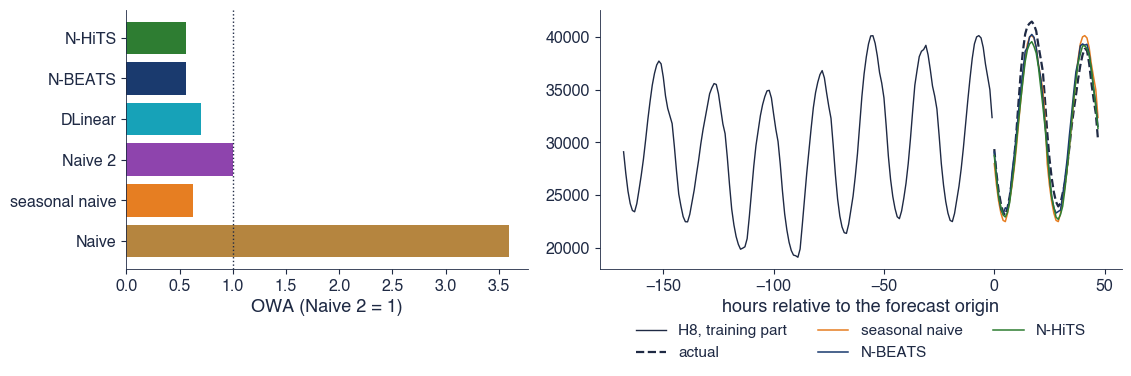

{'Naive': 3.593, 'seasonal naive': 0.628, 'Naive 2': 1.0, 'DLinear': 0.698, 'N-BEATS': 0.556, 'N-HiTS': 0.558}


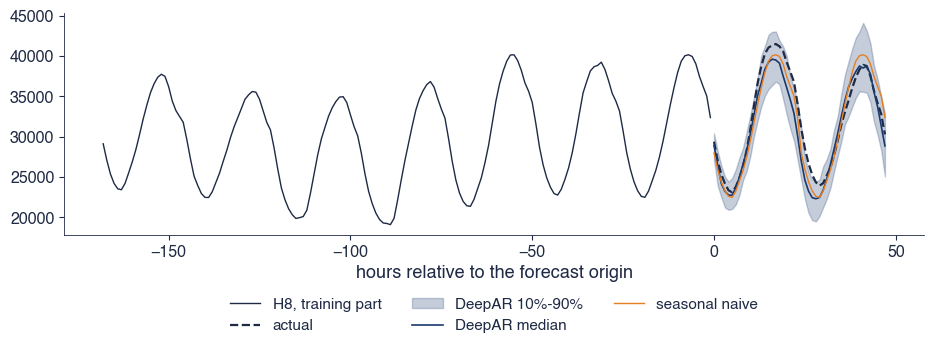

{'seasonal naive': {'wql': 0.03748204133912313, 'cov80': 0.802133655394525, 'smape': 13.819160856163332}, 'budget': {'500': {'wql': 0.03442303603968607, 'cov80': 0.7052133655394525, 'smape': 14.097710056349522}, '1000': {'wql': 0.03380195483262514, 'cov80': 0.8295591787439613, 'smape': 13.744917358190358}}, 'DeepAR': {'wql': 0.03380195483262514, 'cov80': 0.8295591787439613, 'smape': 13.744917358190358}, 'steps': 1000, 'C': 168, 'samples': 100}


In [12]:
def naive2(x, H, m):
    """Naive 2 of M4: seasonal adjustment by classical multiplicative decomposition if the lag-m autocorrelation is
    significant at 90% (|r_m| > 1.645 sqrt((1 + 2 sum_{k<m} r_k^2)/n)), then the naive forecast, then reseasonalise."""
    x = np.asarray(x, float)
    n = len(x)
    xc = x - x.mean()
    r = np.array([xc[k:] @ xc[:n - k] for k in range(m + 1)]) / (xc @ xc)
    seasonal = abs(r[m]) > 1.645 * np.sqrt((1 + 2 * np.sum(r[1:m] ** 2)) / n)
    if not seasonal:
        return np.repeat(x[-1], H)
    ma = pd.Series(x).rolling(m, center=True).mean().rolling(2, center=True).mean().shift(-1).values
    ratio = x / ma
    si = np.array([np.nanmean(ratio[k::m]) for k in range(m)])
    si = si / si.mean()
    s_all = si[np.arange(n) % m]
    adj = x / s_all
    return adj[-1] * si[np.arange(n, n + H) % m]


def m4_windows(train, L, H, per_series=60, seed=0):
    """Training windows of the global models: per_series random windows (input L, output H) from each series."""
    rng = np.random.default_rng(seed)
    X, Y = [], []
    for s in train:
        if len(s) < L + H:
            continue
        for a in rng.integers(0, len(s) - L - H + 1, per_series):
            X.append(s[a:a + L])
            Y.append(s[a + L:a + L + H])
    return np.array(X), np.array(Y)


def scaled_mae(pred, target):
    """MAE on the scale of each window's input level (the loss of the global models)."""
    return (pred - target).abs().mean()


def m4_global(train, H, L, kind, seeds=(0, 1, 2), epochs=30, per_series=60):
    """Global N-BEATS (generic, three blocks), N-HiTS (pools 8, 4, 1) or DLinear trained on windows of all series,
    each window divided by the mean absolute level of its input; ensemble = median of the seeds."""
    X, Y = m4_windows(train, L, H, per_series)
    sc = np.abs(X).mean(1, keepdims=True)
    Xs, Ys = X / sc, Y / sc
    ctx = np.array([s[-L:] for s in train])
    csc = np.abs(ctx).mean(1, keepdims=True)
    fs = []
    for s in seeds:
        net = {'N-BEATS': lambda: NBeatsNet(L, H, 256, 3, (1, 1, 1)),
               'N-HiTS': lambda: NBeatsNet(L, H, 256, 3, (8, 4, 1), (max(H // 12, 2), H // 4, H)),
               'DLinear': lambda: LinearNet(L, H, 'dlinear')}[kind]()
        perm = np.random.default_rng(s).permutation(len(Xs))
        net = fit_torch(net, Xs[perm], Ys[perm], epochs=epochs, lr=1e-3, batch=512, val_frac=0.1, patience=4, seed=s, loss='mae')
        fs.append(predict_torch(net, ctx / csc) * csc)
    return np.median(fs, 0)


def m4_official(methods=('Naive', 'sNaive', 'Naive2', 'Theta', 'MLP', 'RNN', '118', '245')):
    """Hourly sMAPE, MASE and OWA of the M4 evaluation file ('Evaluation and Ranks.xlsx', M4-methods repository):
    the benchmarks, the ML benchmarks MLP and RNN, Smyl (118, the winner) and Montero-Manso et al. (245)."""
    d = pd.read_excel(io.BytesIO(get_bytes('https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Evaluation%20and%20Ranks.xlsx')),
                      sheet_name='Point Forecasts-Frequency', header=None).iloc[2:, [0, 6, 13, 20]]
    d.columns = ['method', 'smape', 'mase', 'owa']
    d['method'] = d['method'].astype(str)
    d = d[d['method'].isin(methods)].set_index('method').astype(float)
    return {k: dict(smape=float(r.smape), mase=float(r.mase), owa=float(r.owa)) for k, r in d.iterrows()}


def m4_scores(train, test, F, m):
    """sMAPE and MASE per series and the OWA of each method against Naive 2 (M4 definitions)."""
    out = {}
    for k, f in F.items():
        out[k] = dict(smape=float(np.mean([smape(test[i], f[i]) for i in range(len(train))])),
                      mase=float(np.mean([mase(test[i], f[i], train[i], m) for i in range(len(train))])))
    for k in out:
        out[k]['owa'] = 0.5 * (out[k]['smape'] / out['Naive 2']['smape'] + out[k]['mase'] / out['Naive 2']['mase'])
    return out


def fig_m4(save_it=True, seeds=(0, 1, 2), epochs=30):
    train, test, ids = m4_hourly()
    H, m, L = M4H['H'], M4H['m'], M4H['L']
    F = {'Naive': np.array([np.repeat(s[-1], H) for s in train]),
         'seasonal naive': np.array([np.tile(s[-m:], H // m) for s in train]),
         'Naive 2': np.array([naive2(s, H, m) for s in train])}
    if TORCH:
        for k in ('DLinear', 'N-BEATS', 'N-HiTS'):
            F[k] = m4_global(train, H, L, k, seeds=seeds, epochs=epochs)
    S = m4_scores(train, test, F, m)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={'width_ratios': [1, 1.3]})
    ks = list(F)
    cols = [st.Amber, st.Orange, st.Purple, st.Teal, st.MainBlue, st.Forest]
    axs[0].barh(range(len(ks)), [S[k]['owa'] for k in ks], color=cols[:len(ks)])
    axs[0].set_yticks(range(len(ks)))
    axs[0].set_yticklabels(ks)
    axs[0].axvline(1, color=st.DarkText, ls=':', lw=1)
    axs[0].set_xlabel('OWA (Naive 2 = 1)')
    i = 7
    axs[1].plot(np.arange(-168, 0), train[i][-168:], color=st.DarkText, lw=1, label=f'{ids[i]}, training part')
    axs[1].plot(np.arange(H), test[i], color=st.DarkText, lw=1.6, ls='--', label='actual')
    for k, c in (('seasonal naive', st.Orange), ('N-BEATS', st.MainBlue), ('N-HiTS', st.Forest)):
        if k in F:
            axs[1].plot(np.arange(H), F[k][i], color=c, lw=1.1, label=k)
    axs[1].set_xlabel('hours relative to the forecast origin')
    st.legend_outside_bottom(axs[1], ncol=3, y=-0.16)
    plt.tight_layout()
    save('ats_ch12_m4', save_it)
    _MEM['m4F'] = F
    try:
        off = m4_official()
    except Exception:                                   # the official file is optional (openpyxl, network)
        off = {}
    return dict(scores=S, official=off, n=len(train), H=H, L=L, seeds=len(seeds))


def fig_deepar(save_it=True, steps=4000, n_samples=100, checkpoints=(500, 1000, 2000)):
    """DeepAR-type Gaussian LSTM, global over the 414 M4 hourly series (lags 1, 24, 168; context 168, horizon 48);
    weighted quantile loss (deciles), 80% coverage, sMAPE of the median, also at earlier training checkpoints;
    benchmark: seasonal naive with quantiles from its one-season-ahead training errors (spread growing with the
    number of seasons ahead)."""
    train, test, ids = m4_hourly()
    H, m = M4H['H'], M4H['m']
    C, M = 168, 168
    hist = np.array([s[-(M + C):] for s in train])
    starts = np.array([len(s) - M - C for s in train])
    sn = np.array([np.tile(s[-m:], H // m) for s in train])
    Qsn = []
    for i, s in enumerate(train):
        e = s[m:] - s[:-m]
        Qsn.append(sn[i][None, :] + np.quantile(e, TAUS9)[:, None] * np.sqrt(1 + np.arange(H) // m)[None, :])

    def score(Q):
        wql = np.sum([2 * pinball(test, Q[:, j], t).sum() for j, t in enumerate(TAUS9)]) / np.abs(test).sum() / len(TAUS9)
        return dict(wql=float(wql), cov80=float(np.mean((test >= Q[:, 0]) & (test <= Q[:, -1]))),
                    smape=float(np.mean([smape(test[i], Q[i, 4]) for i in range(len(test))])))
    out = {'seasonal naive': score(np.array(Qsn))}
    Qd = None
    if TORCH:
        net = deepar_train(train, C, H, steps=steps, checkpoints=checkpoints)
        final = {k: v.clone() for k, v in net.state_dict().items()}
        out['budget'] = {}
        for c in list(checkpoints) + [steps]:
            net.load_state_dict(net.checkpoints[c] if c != steps else final)
            Q = np.quantile(deepar_sample(net, hist, starts, C, H, n_samples), TAUS9, axis=1).transpose(1, 0, 2)
            out['budget'][str(c)] = score(Q)
        out['DeepAR'] = out['budget'][str(steps)]
        Qd = Q
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    i = 7
    ax.plot(np.arange(-168, 0), train[i][-168:], color=st.DarkText, lw=1, label=f'{ids[i]}, training part')
    ax.plot(np.arange(H), test[i], color=st.DarkText, lw=1.6, ls='--', label='actual')
    if Qd is not None:
        ax.fill_between(np.arange(H), Qd[i][0], Qd[i][-1], color=st.MainBlue, alpha=0.25, label='DeepAR 10%-90%')
        ax.plot(np.arange(H), Qd[i][4], color=st.MainBlue, lw=1.2, label='DeepAR median')
    ax.plot(np.arange(H), sn[i], color=st.Orange, lw=1, label='seasonal naive')
    ax.set_xlabel('hours relative to the forecast origin')
    st.legend_outside_bottom(ax, ncol=3, y=-0.22)
    plt.tight_layout()
    save('ats_ch12_deepar', save_it)
    out['steps'], out['C'], out['samples'] = steps, C, n_samples
    return out


r = fig_m4(save_it=False, seeds=(0,))
print({k: round(v['owa'], 3) for k, v in r['scores'].items()})
print(fig_deepar(save_it=False, steps=1000, checkpoints=(500,)))

## 7. Interpretation and honest benchmarks

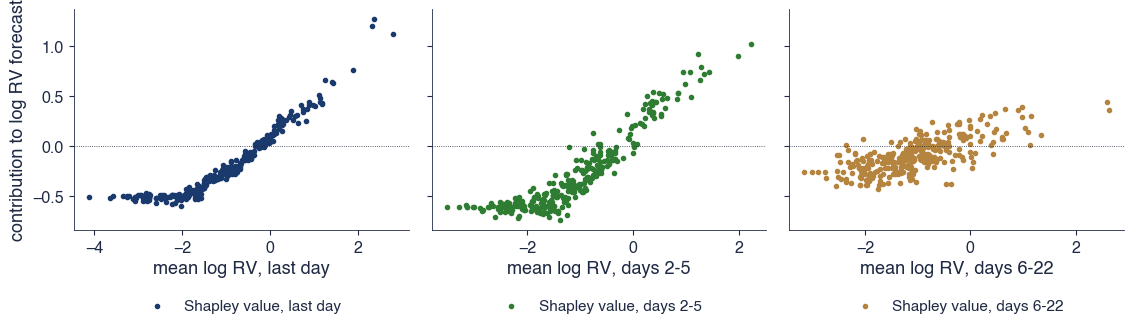

{'share': [0.36526564635327563, 0.46034435214296765, 0.17439000150375672], 'base': -0.34277882370493107, 'additivity': 1.1102230246251565e-15, 'har': [0.281346221196381, 0.502818884755113, 0.17435259827716823], 'slopes': [0.2627801094336047, 0.3436331089095427, 0.13649167248220634], 'n_eval': 300, 'n_bg': 100}


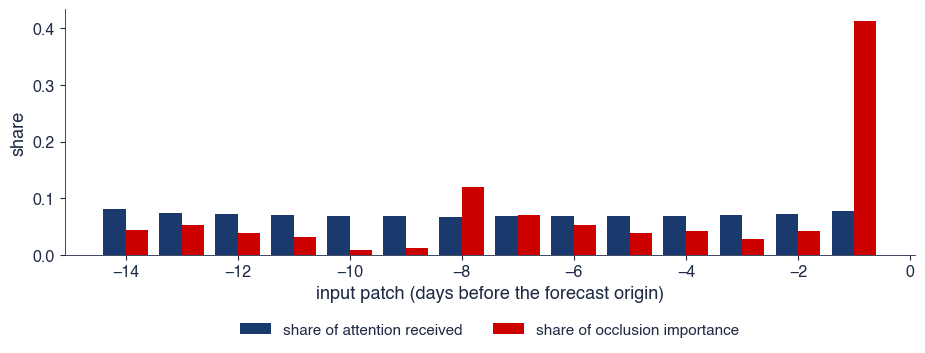

{'rho': 0.2527472527472528, 'top_att': 14, 'top_occ': 1, 'share_last_att': 0.0773409754037857, 'share_last_occ': 0.41318816679534054, 'n_tok': 14}


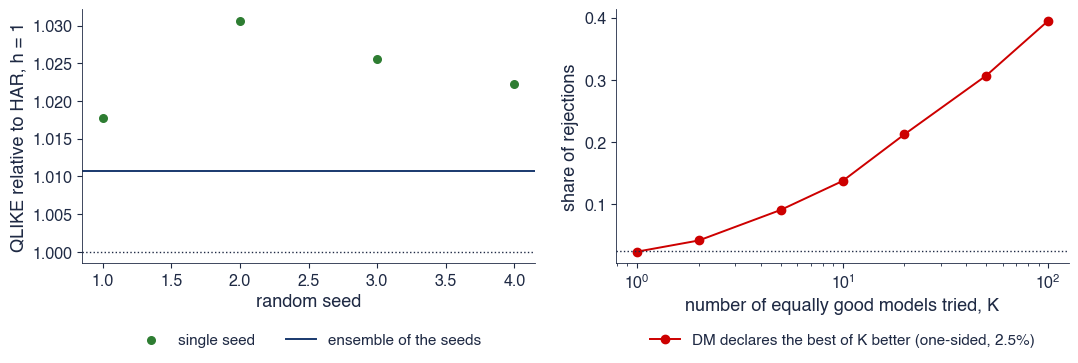

{'seeds': {'rel': [1.0176741577356239, 1.0306445820469088, 1.0255351509339732, 1.0222435445803617], 'ens': 1.01067829407246, 'best': 1.0176741577356239, 'worst': 1.0306445820469088, 'med': 1.0238893477571676, 'n': 4}, 'sim': {'1': {'gain': -0.0004553008283586955, 'reject': 0.024}, '2': {'gain': 0.008338913936095893, 'reject': 0.042}, '5': {'gain': 0.016508409199023934, 'reject': 0.091}, '10': {'gain': 0.021710320403087336, 'reject': 0.1375}, '20': {'gain': 0.02620658513814493, 'reject': 0.2125}, '50': {'gain': 0.031659670274269094, 'reject': 0.307}, '100': {'gain': 0.03520499134221097, 'reject': 0.395}}}


In [13]:
def fig_shap(save_it=True, n_eval=300, n_bg=100):
    """Exact Shapley values of three lag groups (last day, days 2-5, days 6-22) for boosting on the 22 lags of S&P 500
    log RV (h = 1), trained before the first forecast origin; evaluated on the forecast period."""
    from sklearn.ensemble import HistGradientBoostingRegressor as HGB
    y = np.log(omi('.SPX').values)
    W = rv_windows(y, RV['lags'])
    tw = np.arange(RV['lags'] - 1, len(y))
    ok = tw + 1 < len(y)
    W, tw = W[ok], tw[ok]
    tr = tw + 1 <= RV['first']
    m = HGB(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=50, random_state=SEED).fit(W[tr], y[tw[tr] + 1])
    rng = np.random.default_rng(SEED)
    te = np.where(~tr)[0]
    ev = rng.choice(te, n_eval, replace=False)
    bg = rng.choice(np.where(tr)[0], n_bg, replace=False)
    groups = [[21], [17, 18, 19, 20], list(range(17))]
    phi, base = shapley_groups(m.predict, W[ev], W[bg], groups)
    feat = np.column_stack([W[ev][:, g].mean(1) for g in groups])
    fig, axs = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
    names = ['last day', 'days 2-5', 'days 6-22']
    for j, (ax, c) in enumerate(zip(axs, (st.MainBlue, st.Forest, st.Amber))):
        ax.scatter(feat[:, j], phi[:, j], s=9, color=c, label=f'Shapley value, {names[j]}')
        ax.axhline(0, color=st.DarkText, lw=0.6, ls=':')
        ax.set_xlabel(f'mean log RV, {names[j]}')
        st.legend_outside_bottom(ax, ncol=1, y=-0.25)
    axs[0].set_ylabel('contribution to log RV forecast')
    plt.tight_layout()
    save('ats_ch12_shap', save_it)
    imp = np.abs(phi).mean(0)
    # HAR coefficients estimated on the same training sample
    A = har_feats(W[tr])
    b = np.linalg.lstsq(np.column_stack([np.ones(len(A)), A]), y[tw[tr] + 1], rcond=None)[0]
    pred = m.predict(W[ev])
    return dict(share=[float(v / imp.sum()) for v in imp], base=float(base), additivity=float(np.max(np.abs(phi.sum(1) + base - pred))),
                har=[float(v) for v in b[1:]], slopes=[float(np.polyfit(feat[:, j], phi[:, j], 1)[0]) for j in range(3)],
                n_eval=n_eval, n_bg=n_bg)


def torch_no_grad():
    import torch
    return torch.no_grad()


def torch_tensor(X):
    import torch
    return torch.as_tensor(np.asarray(X, np.float32))


def fig_attention(save_it=True, n=1000):
    """Attention received by each input patch (average over heads, queries and test windows) against occlusion
    importance (increase of the MSE when the patch is replaced by the window mean), for the Transformer at H = 96."""
    from scipy.stats import spearmanr
    keep = _MEM.get('zeng_keep')
    if keep is None or 'net' not in keep:
        fig_zeng(save_it=False, seeds=(0,))
        keep = _MEM['zeng_keep']
    net, X, Y = keep['net'], keep['Xte'][:n], keep['Yte'][:n]
    base = np.mean((predict_torch(net, X) - Y) ** 2)
    with torch_no_grad():
        net(torch_tensor(X))
    A = net.attn.numpy().mean(axis=(0, 1))                              # attention received by each key patch
    T = net.n_tok
    occ = []
    for j in range(T):
        Z = X.copy()
        sl = slice(X.shape[1] - (T - j) * net.patch, X.shape[1] - (T - j - 1) * net.patch)
        Z[:, sl] = Z.mean(1, keepdims=True)
        occ.append(np.mean((predict_torch(net, Z) - Y) ** 2) - base)
    occ = np.array(occ)
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    x = np.arange(T) - T
    ax.bar(x - 0.2, A / A.sum(), 0.4, color=st.MainBlue, label='share of attention received')
    ax.bar(x + 0.2, np.maximum(occ, 0) / np.maximum(occ, 0).sum(), 0.4, color=st.IDAred, label='share of occlusion importance')
    ax.set_xlabel('input patch (days before the forecast origin)')
    ax.set_ylabel('share')
    st.legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save('ats_ch12_attention', save_it)
    rho = spearmanr(A, occ)[0]
    return dict(rho=float(rho), top_att=int(T - np.argmax(A)), top_occ=int(T - np.argmax(occ)),
                share_last_att=float(A[-1] / A.sum()), share_last_occ=float(max(occ[-1], 0) / np.maximum(occ, 0).sum()),
                n_tok=int(T))


def seeds_snooping(rv=None, n_seeds=10, h=1, epochs=60):
    """MLP forecasts of S&P 500 RV with n_seeds random seeds: QLIKE ratio to HAR of each seed, of the seed ensemble,
    and of the seed that is best on the test period (data snooping)."""
    rv = omi('.SPX') if rv is None else rv
    Fh = rv_forecasts(rv, models=('HAR',), horizons=(h,))[h]
    ql_har = qlike(Fh['rv'], Fh['HAR'])
    rel, logs = [], []
    for s in range(n_seeds):
        F = rv_forecasts(rv, models=('MLP',), horizons=(h,), seeds=(s,), epochs=epochs)[h]
        rel.append(float(qlike(F['rv'], F['MLP']).mean() / ql_har.mean()))
        logs.append(np.log(F['MLP'].values))
    ens = np.exp(np.mean(logs, 0))
    rel_ens = float(qlike(Fh['rv'], ens).mean() / ql_har.mean())
    return dict(rel=rel, ens=rel_ens, best=float(min(rel)), worst=float(max(rel)), med=float(np.median(rel)), n=n_seeds)


def snooping_sim(K=(1, 2, 5, 10, 20, 50, 100), T=2500, reps=2000, rho=0.5, seed=SEED):
    """K forecasting models with the same expected loss; loss differentials against a benchmark are N(0, 1) per day
    with pairwise correlation rho across models. Expected 'gain' of the model that looks best on a test period of
    T days, in standard deviations of the daily differential, and the share of DM tests rejecting at 5% for it."""
    rng = np.random.default_rng(seed)
    out = {}
    for k in K:
        common = rng.normal(size=(reps, 1))
        own = rng.normal(size=(reps, k))
        mbar = (np.sqrt(rho) * common + np.sqrt(1 - rho) * own) / np.sqrt(T)   # mean differential over T days
        best = mbar.max(axis=1)
        out[k] = dict(gain=float(np.mean(best)), reject=float(np.mean(best * np.sqrt(T) > 1.96)))
    return out


def fig_snooping(save_it=True, n_seeds=10, epochs=60):
    s = seeds_snooping(n_seeds=n_seeds, epochs=epochs)
    sim = snooping_sim()
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.9))
    axs[0].scatter(np.arange(1, len(s['rel']) + 1), s['rel'], color=st.Forest, s=30, label='single seed')
    axs[0].axhline(s['ens'], color=st.MainBlue, lw=1.4, label='ensemble of the seeds')
    axs[0].axhline(1, color=st.DarkText, ls=':', lw=1)
    axs[0].set_xlabel('random seed')
    axs[0].set_ylabel('QLIKE relative to HAR, h = 1')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.22)
    K = list(sim)
    axs[1].plot(K, [sim[k]['reject'] for k in K], 'o-', color=st.IDAred, label='DM declares the best of K better (one-sided, 2.5%)')
    axs[1].axhline(0.025, color=st.DarkText, ls=':', lw=1)
    axs[1].set_xscale('log')
    axs[1].set_xlabel('number of equally good models tried, K')
    axs[1].set_ylabel('share of rejections')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.22)
    plt.tight_layout()
    save('ats_ch12_snooping', save_it)
    return dict(seeds=s, sim={str(k): v for k, v in sim.items()})


print(fig_shap(save_it=False))
print(fig_attention(save_it=False))
print(fig_snooping(save_it=False, n_seeds=4, epochs=30))

## 8. AI mini-case: do learners beat HAR across markets?

- Two indices and boosting only here (six indices and an MLP on the slides).

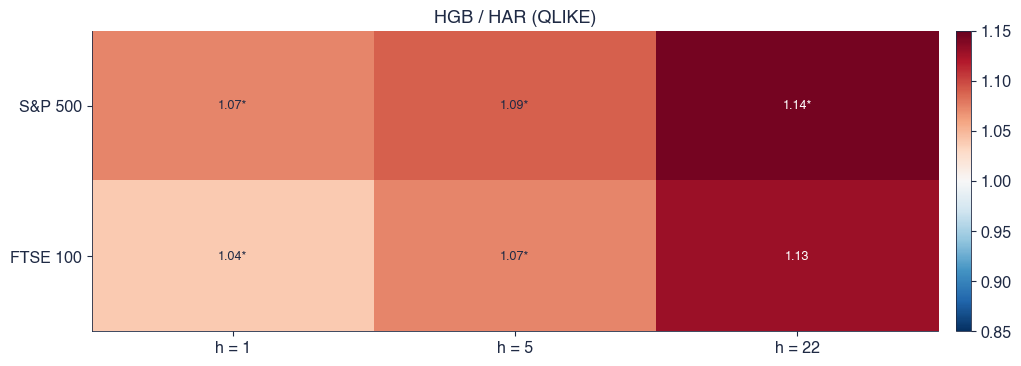

{'n': 6, 'better': 0, 'sig_better': 0, 'sig_worse': 5, 'rel_min': 1.039658454228963, 'rel_max': 1.143817885390613, 'rel_med': 1.0816354011485156, 'by_model': {'HGB': 1.0816354011485156}, 'by_h': {'1': 1.0566107510193263, '5': 1.0815838081771432, '22': 1.1362350380156228}}


In [14]:
def fig_ai_case(save_it=True, models=('MLP', 'HGB'), epochs=40, symbols=tuple(OMI_NAMES)):
    """Pre-registered grid: six indices x horizons 1, 5, 22 x two learners (MLP, boosting) against HAR, the same
    expanding design; QLIKE ratio and HLN-DM p-value of each cell."""
    rows = []
    for sym in symbols:
        name = OMI_NAMES[sym]
        F = rv_forecasts(omi(sym), models=('HAR',) + tuple(models), epochs=epochs)
        E = evaluate_rv(F)
        for h in RV['horizons']:
            for k in models:
                rows.append(dict(asset=name, h=h, model=k, rel=E[str(h)]['rel'][k], p=E[str(h)]['dm'][k]['p_hln'],
                                 t=E[str(h)]['dm'][k]['hln']))
    t = pd.DataFrame(rows)
    fig, axs = plt.subplots(1, len(models), figsize=(11.5, 3.9), sharey=True)
    for ax, k in zip(np.atleast_1d(axs), models):
        names = [OMI_NAMES[x] for x in symbols]
        M = t[t['model'] == k].pivot(index='asset', columns='h', values='rel').loc[names]
        Pv = t[t['model'] == k].pivot(index='asset', columns='h', values='p').loc[names]
        im = ax.imshow(M.values, cmap='RdBu_r', vmin=0.85, vmax=1.15, aspect='auto')
        for a in range(M.shape[0]):
            for b in range(M.shape[1]):
                ax.text(b, a, f'{M.values[a, b]:.2f}' + ('*' if Pv.values[a, b] < 0.05 else ''), ha='center', va='center',
                        fontsize=9, color='white' if abs(M.values[a, b] - 1) > 0.09 else st.DarkText)
        ax.set_xticks(range(M.shape[1]))
        ax.set_xticklabels([f'h = {h}' for h in M.columns])
        ax.set_yticks(range(M.shape[0]))
        ax.set_yticklabels(M.index)
        ax.set_title(f'{k} / HAR (QLIKE)')
    plt.colorbar(im, ax=axs, fraction=0.03, pad=0.02)
    save('ats_ch12_ai_case', save_it)
    return dict(n=int(len(t)), better=int((t['rel'] < 1).sum()), sig_better=int(((t['rel'] < 1) & (t['p'] < 0.05)).sum()),
                sig_worse=int(((t['rel'] > 1) & (t['p'] < 0.05)).sum()), rel_min=float(t['rel'].min()),
                rel_max=float(t['rel'].max()), rel_med=float(t['rel'].median()),
                by_model={k: float(t[t['model'] == k]['rel'].median()) for k in models},
                by_h={str(h): float(t[t['h'] == h]['rel'].median()) for h in RV['horizons']})


print(fig_ai_case(save_it=False, models=('HGB',), symbols=('.SPX', '.FTSE')))

## Exercises

1. Replace the random forest of the leakage experiment by a k-nearest-neighbour regressor and compare the optimism.
2. Add the 24-hour seasonal lag to the inputs of DLinear and of the patch Transformer and repeat the Zeng protocol.
3. Choose the DeepAR training budget on the last 48 hours of each training series instead of the test period.